In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df = pd.read_csv('../Data/Clusters/All_5_Clustering_Algo_Result_10-30-2024.csv')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2118 entries, 0 to 2117
Data columns (total 40 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Landing_Page_Size_In_KB                      2118 non-null   float64
 1   Same Landing Domain                          2118 non-null   int64  
 2   Has Bank Related Keywords                    2118 non-null   int64  
 3   Has Crypto Related Keywords                  2118 non-null   int64  
 4   Has Card Related Keywords                    2118 non-null   int64  
 5   Unique_Internal_Page_Link_Cnt                2118 non-null   int64  
 6   Unique_External_Page_Link_Cnt                2118 non-null   int64  
 7   Avg_External_Links_Len                       2118 non-null   float64
 8   Stdv_External_Links_Len                      2118 non-null   float64
 9   Ratio_Shortened_URL_And_External_Links       2118 non-null   float64
 10  

In [9]:
# df = df.drop(columns='Unnamed: 0', axis=1)

In [10]:
cluster_1 = df.loc[df['Majority Voting Label']==0]
cluster_2 = df.loc[df['Majority Voting Label']==1]
cluster_3 = df.loc[df['Majority Voting Label']==2]

In [11]:
print(len(cluster_1),len(cluster_2), len(cluster_3))

1149 388 581


In [12]:
print(dict(cluster_1['TLD'].value_counts()))
print(dict(cluster_2['TLD'].value_counts()))
print(dict(cluster_3['TLD'].value_counts()))

{'com': 411, 'org': 308, 'de': 93, 'ch': 24, 'eu': 24, 'net': 21, 'co.uk': 21, 'info': 18, 'ca': 16, 'nl': 15, 'fr': 12, 'org.uk': 12, 'at': 11, 'dk': 10, 'us': 8, 'io': 6, 'co': 6, 'online': 5, 'se': 5, 'be': 5, 'it': 5, 'art': 5, 'pl': 5, 'uk': 4, 'world': 4, 'cz': 3, 'help': 3, 'today': 3, 'foundation': 3, 'shop': 3, 'me': 3, 'pp.ua': 3, 'com.au': 2, 'hu': 2, 'care': 2, 'site': 2, 'fi': 2, 'tech': 2, 'charity': 2, 'team': 2, 'fund': 2, 'org.au': 2, 'center': 2, 'life': 2, 'lt': 2, 'xyz': 2, 'space': 2, 'com.pl': 2, 'jp': 2, 'com.ua': 2, 'city': 1, 'am': 1, 'nz': 1, 'ps': 1, 'best': 1, 'group': 1, 'quest': 1, 'one': 1, 'si': 1, 'link': 1, 'in': 1, 'family': 1, 'live': 1, 'company': 1, 'school': 1, 'work': 1, 'market': 1, 'army': 1, 'nu': 1, 'ru': 1, 'lu': 1, 'ie': 1, 'pt': 1, 'brussels': 1, 'community': 1, 'dev': 1, 'is': 1, 'jetzt': 1, 'lv': 1, 'how': 1, 'ro': 1, 'clothing': 1, 'blog': 1, 'media': 1, 'church': 1, 'network': 1, 'app': 1, 'hk': 1}
{'com': 136, 'org': 70, 'de': 48, 'in

In [13]:
cluster_2

,Landing_Page_Size_In_KB,Same Landing Domain,Has Bank Related Keywords,Has Crypto Related Keywords,Has Card Related Keywords,Unique_Internal_Page_Link_Cnt,Unique_External_Page_Link_Cnt,Avg_External_Links_Len,Stdv_External_Links_Len,Ratio_Shortened_URL_And_External_Links,...,Hierarchical Label,DBSCAN Label,GMM Label,Majority Voting Label,IPQS_Flag,Domain,TLD,Searched_URL,Status Code,Parked Status
15,1.06,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,1,aboutukraine.org,org,https://www.aboutukraine.org,200,1
22,2.77,0,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,0,actions-fondations-ukraine.org,org,https://www.actions-fondations-ukraine.org,-1,0
40,0.11,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,1,aidtoukraine.org,org,https://www.aidtoukraine.org,-1,0
51,3.03,1,0,1,0,1,0,0.0,0.0,0.0,...,1,1,1,1,0,aidukrainefund.org,org,https://www.aidukrainefund.org,200,0
53,6.60,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,0,aidukrainetoday.org,org,https://www.aidukrainetoday.org,200,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091,1.19,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,0,workingukraine.com,com,https://www.workingukraine.com,200,0
2104,0.83,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,1,xn--ukraine-hilfe-sddeutschland-w3c.de,de,https://www.xn--ukraine-hilfe-sddeutschland-w3...,200,0
2105,0.83,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,1,xn--ukraine-hilfe-thringen-7lc.de,de,https://www.xn--ukraine-hilfe-thringen-7lc.de,200,0
2108,1.89,1,0,0,0,1,0,0.0,0.0,0.0,...,1,1,1,1,1,yoga-for-ukraine.com,com,https://www.yoga-for-ukraine.com,-1,0


In [14]:
np.mean(cluster_2['Domain Letter Count'])

14.981958762886597

In [15]:
def dig_cnt(cluster):
  cnt = 0
  for i in cluster['Domain Digit Rate']:
    if i:
      cnt+=1
  return cnt

In [16]:
def theme_cnt(cluster):
  cnt = 0
  a = cluster['Money Keyword Check'].to_list()
  b = cluster['Help Keyword Check'].to_list()
  c = cluster['Campaign Keyword Check'].to_list()
  d = cluster['War Keyword Check'].to_list()
  for i in range(len(a)):
    if a[i] or b[i] or c[i] or d[i]:
      cnt+=1
  return cnt

In [17]:
def hyphen_cnt(cluster):
  cnt = 0
  for i in cluster['Domain Hyphen Count']:
    if i:
      cnt+=1
  return cnt

In [18]:
def for_cnt(cluster):
  cnt = 0
  for i in cluster['For and To Keyword Check']:
    if i:
      cnt+=1
  return cnt

In [19]:
def _4_cnt(cluster):
  cnt = 0
  for i in cluster['Number Instead of Word']:
    if i:
      cnt+=1
  return cnt

In [20]:
def short_url_cnt(cluster):
  cnt = 0
  for i in cluster['Ratio_Shortened_URL_And_External_Links']:
    if i>0:
      cnt+=1
  return cnt

In [21]:
print(dig_cnt(cluster_1),100*dig_cnt(cluster_1)/len(cluster_1))
print(dig_cnt(cluster_2),100*dig_cnt(cluster_2)/len(cluster_2))
print(dig_cnt(cluster_3),100*dig_cnt(cluster_3)/len(cluster_3))

103 8.96431679721497
50 12.88659793814433
63 10.843373493975903


In [22]:
print(theme_cnt(cluster_1),100*theme_cnt(cluster_1)/len(cluster_1))
print(theme_cnt(cluster_2),100*theme_cnt(cluster_2)/len(cluster_2))
print(theme_cnt(cluster_3),100*theme_cnt(cluster_3)/len(cluster_3))

329 28.633594429939077
108 27.835051546391753
169 29.08777969018933


In [23]:
print(hyphen_cnt(cluster_1),100*hyphen_cnt(cluster_1)/len(cluster_1))
print(hyphen_cnt(cluster_2),100*hyphen_cnt(cluster_2)/len(cluster_2))
print(hyphen_cnt(cluster_3),100*hyphen_cnt(cluster_3)/len(cluster_3))

242 21.061792863359443
88 22.68041237113402
139 23.924268502581757


In [24]:
print(for_cnt(cluster_1),100*for_cnt(cluster_1)/len(cluster_1))
print(for_cnt(cluster_2),100*for_cnt(cluster_2)/len(cluster_2))
print(for_cnt(cluster_3),100*for_cnt(cluster_3)/len(cluster_3))

185 16.100957354221062
75 19.329896907216494
107 18.416523235800344


In [25]:
print(_4_cnt(cluster_1),100*_4_cnt(cluster_1)/len(cluster_1))
print(_4_cnt(cluster_2),100*_4_cnt(cluster_2)/len(cluster_2))
print(_4_cnt(cluster_3),100*_4_cnt(cluster_3)/len(cluster_3))

79 6.8755439512619665
45 11.597938144329897
50 8.605851979345955


In [26]:
print(short_url_cnt(cluster_1),100*short_url_cnt(cluster_1)/len(cluster_1))
print(short_url_cnt(cluster_2),100*short_url_cnt(cluster_2)/len(cluster_2))
print(short_url_cnt(cluster_3),100*short_url_cnt(cluster_3)/len(cluster_3))

169 14.708442123585726
0 0.0
73 12.564543889845094


In [27]:
import statistics as st

In [28]:
print(st.mean(cluster_1['Domain Letter Count']))
print(st.stdev(cluster_1['Domain Letter Count']))
print(st.median(cluster_1['Domain Letter Count']))
print(st.mode(cluster_1['Domain Letter Count']))

15.44821583986075
4.264365845570808
15
14


In [29]:
def domain_len_ranges(domain):
  ranges={'_1-14':0,'_15-19':0,'_20-29':0,'>30':0}
  for i in domain:
    if i<15:
      ranges['_1-14']+=1
    elif i>14 and i<20:
      ranges['_15-19']+=1
    elif i>19 and i<30:
      ranges['_20-29']+=1
    else:
      ranges['>30']+=1

  print(ranges,100*(ranges['_15-19']+ranges['_20-29']+ranges['>30'])/len(domain))


In [30]:
domain_len_ranges(cluster_1['Domain Letter Count'])
domain_len_ranges(cluster_2['Domain Letter Count'])
domain_len_ranges(cluster_3['Domain Letter Count'])

{'_1-14': 547, '_15-19': 415, '_20-29': 179, '>30': 8} 52.39338555265448
{'_1-14': 203, '_15-19': 141, '_20-29': 44, '>30': 0} 47.68041237113402
{'_1-14': 261, '_15-19': 226, '_20-29': 88, '>30': 6} 55.077452667814114


In [31]:
print(st.mean(cluster_1['Domain Letter Count']),st.stdev(cluster_1['Domain Letter Count']),st.median(cluster_1['Domain Letter Count']),st.mode(cluster_1['Domain Letter Count']))
print(st.mean(cluster_2['Domain Letter Count']),st.stdev(cluster_2['Domain Letter Count']),st.median(cluster_2['Domain Letter Count']),st.mode(cluster_2['Domain Letter Count']))
print(st.mean(cluster_3['Domain Letter Count']),st.stdev(cluster_3['Domain Letter Count']),st.median(cluster_3['Domain Letter Count']),st.mode(cluster_3['Domain Letter Count']))

15.44821583986075 4.264365845570808 15 14
14.981958762886597 3.590424284249811 14.0 14
15.557659208261619 4.407540250862276 15 14


In [32]:
print(st.mean(cluster_1['Domain Digit Rate']),st.stdev(cluster_1['Domain Digit Rate']),st.median(cluster_1['Domain Digit Rate']),st.mode(cluster_1['Domain Digit Rate']))
print(st.mean(cluster_2['Domain Digit Rate']),st.stdev(cluster_2['Domain Digit Rate']),st.median(cluster_2['Domain Digit Rate']),st.mode(cluster_2['Domain Digit Rate']))
print(st.mean(cluster_3['Domain Digit Rate']),st.stdev(cluster_3['Domain Digit Rate']),st.median(cluster_3['Domain Digit Rate']),st.mode(cluster_3['Domain Digit Rate']))

0.009167972149695388 0.034524275423712 0.0 0.0
0.01054639175257732 0.03143757051141336 0.0 0.0
0.01044750430292599 0.03639608848065671 0.0 0.0


In [33]:
print(st.mean(cluster_1['Spamhaus TLD Rank']),st.stdev(cluster_1['Spamhaus TLD Rank']),st.median(cluster_1['Spamhaus TLD Rank']),st.mode(cluster_1['Spamhaus TLD Rank']))
print(st.mean(cluster_2['Spamhaus TLD Rank']),st.stdev(cluster_2['Spamhaus TLD Rank']),st.median(cluster_2['Spamhaus TLD Rank']),st.mode(cluster_2['Spamhaus TLD Rank']))
print(st.mean(cluster_3['Spamhaus TLD Rank']),st.stdev(cluster_3['Spamhaus TLD Rank']),st.median(cluster_3['Spamhaus TLD Rank']),st.mode(cluster_3['Spamhaus TLD Rank']))

0.10962576153176676 0.1759581511990736 0.05 0.16
0.1370618556701031 0.21405794160820066 0.13 0.16
0.11862306368330465 0.21058743147380754 0.08 0.16


In [34]:
def within_cluster_analysis_bin_feature(df,cluster_name):
  
  # #for binary column entries
  has_cheap_tld = df['Is Cheapest TLD'].to_list()
  has_cc = df['Is Combined TLD'].to_list()
  xn = df['xn-- Present'].to_list()
  money = df['Money Keyword Check'].to_list()
  help = df['Help Keyword Check'].to_list()
  camp = df['Campaign Keyword Check'].to_list()
  war = df['War Keyword Check'].to_list()
  for_to = df['For and To Keyword Check'].to_list()
  _4_2 = df['Number Instead of Word'].to_list()
  ssl = df['Is SSL Certificate Retrievable'].to_list()
  who = df['Is WhoIs Registrar Available'].to_list()

  column = ['Is Cheapest TLD', 'Is Combined TLD', 'Is xn-- Present','Money Keyword Check','Help Keyword Check',
            'Campaign Keyword Check','War Keyword Check','For and To Keyword Check','Number Instead of Word','Is SSL Certificate Retrievable','Is WhoIs Registrar Available']
  count_val = {
    'Ones': np.array([has_cheap_tld.count(1),has_cc.count(1),xn.count(1),money.count(1),help.count(1),camp.count(1),war.count(1),for_to.count(1),_4_2.count(1),ssl.count(1),who.count(1)]),
    'Zeroes': np.array([has_cheap_tld.count(0),has_cc.count(0),xn.count(0),money.count(0),help.count(0),camp.count(0),war.count(0),for_to.count(0),_4_2.count(0),ssl.count(0),who.count(0)]),
  }
  width = 0.8  # the width of the bars: can also be len(x) sequence


  fig, ax = plt.subplots(figsize=(36, 12))
  bottom = np.zeros(len(column))

  for label, val in count_val.items():
    p = ax.bar(column, val, width, label=label, bottom=bottom)
    bottom += val

    ax.bar_label(p, label_type='center')

  ax.set_title('Analysis for the binary Features for '+ cluster_name)
  ax.legend()

  plt.show()

In [35]:
def within_cluster_analysis_num_feature(df,cluster_name):
  # for numerical column entries
  column = ["Spamhaus TLD Rank", "Domain Letter Count", "Domain Digit Rate", "Domain Hyphen Count"]
  stats = {
    'Mean': np.round((st.mean(df['Spamhaus TLD Rank']), st.mean(df['Domain Letter Count']), st.mean(df['Domain Digit Rate']), st.mean(df["Domain Hyphen Count"])),2),
    'Median': np.round((st.median(df['Spamhaus TLD Rank']), st.median(df['Domain Letter Count']), st.median(df['Domain Digit Rate']), st.median(df["Domain Hyphen Count"])),2),
    'Mode': np.round((st.mode(df['Spamhaus TLD Rank']), st.mode(df['Domain Letter Count']), st.mode(df['Domain Digit Rate']), st.mode(df["Domain Hyphen Count"])),2),
    'STD': np.round((st.stdev(df['Spamhaus TLD Rank']), st.stdev(df['Domain Letter Count']), st.stdev(df['Domain Digit Rate']), st.stdev(df["Domain Hyphen Count"])),2),
    'MAX':np.round((max(df['Spamhaus TLD Rank']), max(df['Domain Letter Count']), max(df['Domain Digit Rate']), max(df["Domain Hyphen Count"])),2),
    'MIN':np.round((min(df['Spamhaus TLD Rank']), min(df['Domain Letter Count']), min(df['Domain Digit Rate']), min(df["Domain Hyphen Count"])),2)
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0

  fig, ax = plt.subplots(layout='constrained',figsize=(20,8))

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, 40)
  plt.show()

In [36]:
def within_cluster_analysis_content_bin_feature(df,cluster_name):

  # #for binary column entries
  same_landing_dom = df['Same Landing Domain'].to_list()
  has_bank_text = df['Has Bank Related Keywords'].to_list()
  has_crypto = df['Has Crypto Related Keywords'].to_list()
  has_card = df['Has Card Related Keywords'].to_list()
  has_form = df['Has_Google_Form_External_Link'].to_list()
  has_paypal = df['Has_Paypal_External_Link'].to_list()

  column = ['Same Landing Domain', 'Has Bank Related Keywords', 'Has Crypto Related Keywords','Has Card Related Keywords','Has_Google_Form_External_Link','Has_Paypal_External_Link']
  count_val = {
    'Ones': np.array([same_landing_dom.count(1),has_bank_text.count(1),has_crypto.count(1),has_card.count(1),has_form.count(1),has_paypal.count(1)]),
    'Zeroes': np.array([same_landing_dom.count(0),has_bank_text.count(0),has_crypto.count(0),has_card.count(0),has_form.count(0),has_paypal.count(0)]),
  }

  width = 0.8  # the width of the bars: can also be len(x) sequence

  fig, ax = plt.subplots(figsize=(36, 12))
  bottom = np.zeros(len(column))

  for label, val in count_val.items():
    p = ax.bar(column, val, width, label=label, bottom=bottom)
    bottom += val

    ax.bar_label(p, label_type='center')

  ax.set_title('Analysis for the binary Features for '+ cluster_name)
  ax.legend()
  plt.show()

In [37]:
def within_cluster_analysis_num_content_feature(df,cluster_name,y_lim=700):
  # for numerical column entries
  column = ["Unique_Internal_Page_Link_Cnt", "Unique_External_Page_Link_Cnt", "Avg_External_Links_Len",
            'Stdv_External_Links_Len', 'Ratio_Shortened_URL_And_External_Links', 'Ratio_Social_Media_Links_And_External_Links']
  stats = {
    'Mean': np.round((st.mean(df['Unique_Internal_Page_Link_Cnt']), st.mean(df['Unique_External_Page_Link_Cnt']), st.mean(df["Avg_External_Links_Len"]), st.mean(df["Stdv_External_Links_Len"]), st.mean(df["Ratio_Shortened_URL_And_External_Links"]), st.mean(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'Median': np.round((st.median(df['Unique_Internal_Page_Link_Cnt']), st.median(df['Unique_External_Page_Link_Cnt']), st.median(df["Avg_External_Links_Len"]), st.median(df["Stdv_External_Links_Len"]), st.median(df["Ratio_Shortened_URL_And_External_Links"]), st.median(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'Mode': np.round((st.mode(df['Unique_Internal_Page_Link_Cnt']), st.mode(df['Unique_External_Page_Link_Cnt']), st.mode(df["Avg_External_Links_Len"]), st.mode(df["Stdv_External_Links_Len"]), st.mode(df["Ratio_Shortened_URL_And_External_Links"]), st.mode(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'STD': np.round((st.stdev(df['Unique_Internal_Page_Link_Cnt']), st.stdev(df['Unique_External_Page_Link_Cnt']), st.stdev(df["Avg_External_Links_Len"]), st.stdev(df["Stdv_External_Links_Len"]), st.stdev(df["Ratio_Shortened_URL_And_External_Links"]), st.stdev(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'MAX':np.round((max(df['Unique_Internal_Page_Link_Cnt']), max(df['Unique_External_Page_Link_Cnt']), max(df["Avg_External_Links_Len"]), max(df["Stdv_External_Links_Len"]), max(df["Ratio_Shortened_URL_And_External_Links"]), max(df["Ratio_Social_Media_Links_And_External_Links"])),2),
    'MIN':np.round((min(df['Unique_Internal_Page_Link_Cnt']), min(df['Unique_External_Page_Link_Cnt']), min(df["Avg_External_Links_Len"]), min(df["Stdv_External_Links_Len"]), min(df["Ratio_Shortened_URL_And_External_Links"]), min(df["Ratio_Social_Media_Links_And_External_Links"])),2),
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0
 

  fig, ax = plt.subplots(figsize=(20,8),layout='constrained')

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, y_lim)
  plt.show()

In [38]:
def within_cluster_analysis_num_content2_feature(df,cluster_name,y_lim=5000):
  # for numerical column entries
  column = ["Landing_Page_Size_In_KB"]
  stats = {
    'Mean': np.round((st.mean(df['Landing_Page_Size_In_KB'])),2),
    'Median': np.round((st.median(df['Landing_Page_Size_In_KB'])),2),
    'Mode': np.round((st.mode(df['Landing_Page_Size_In_KB'])),2),
    'STD': np.round((st.stdev(df['Landing_Page_Size_In_KB'])),2),
    'MAX':np.round((max(df['Landing_Page_Size_In_KB'])),2),
    'MIN':np.round((min(df['Landing_Page_Size_In_KB'])),2),
  }

  x = np.arange(len(column))  # the label locations
  width = 0.15  # the width of the bars
  multiplier = 0
 

  fig, ax = plt.subplots(figsize=(20,8),layout='constrained')

  for attribute, measurement in stats.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=5)
    multiplier += 1

  # Add some text for labels, title and custom x-axis tick labels, etc.
  ax.set_ylabel('value')
  ax.set_title('Numerical Feature Analysis of '+ cluster_name)
  ax.set_xticks(x + width, column)
  ax.legend(loc='upper left', ncols=len(column))
  ax.set_ylim(0, y_lim)
  plt.show()

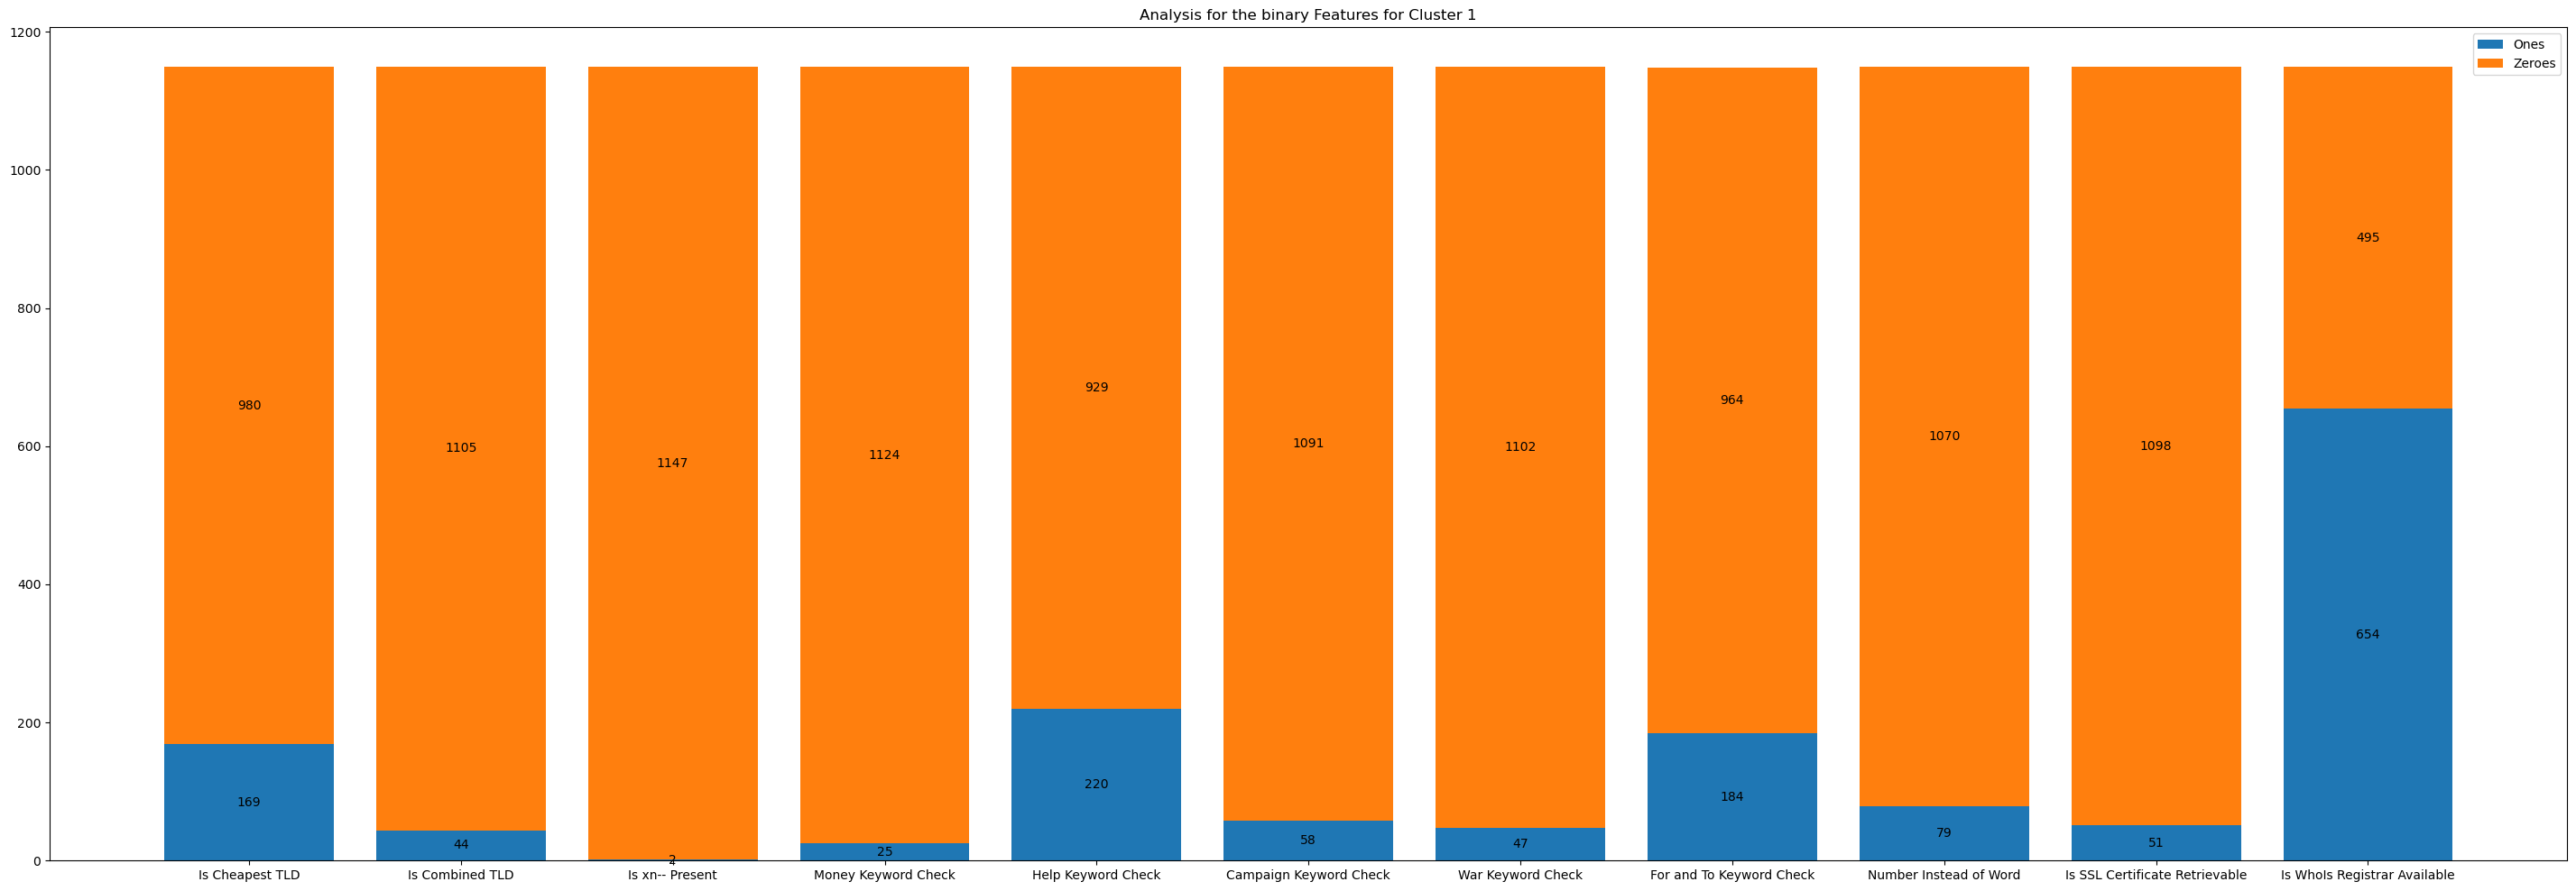

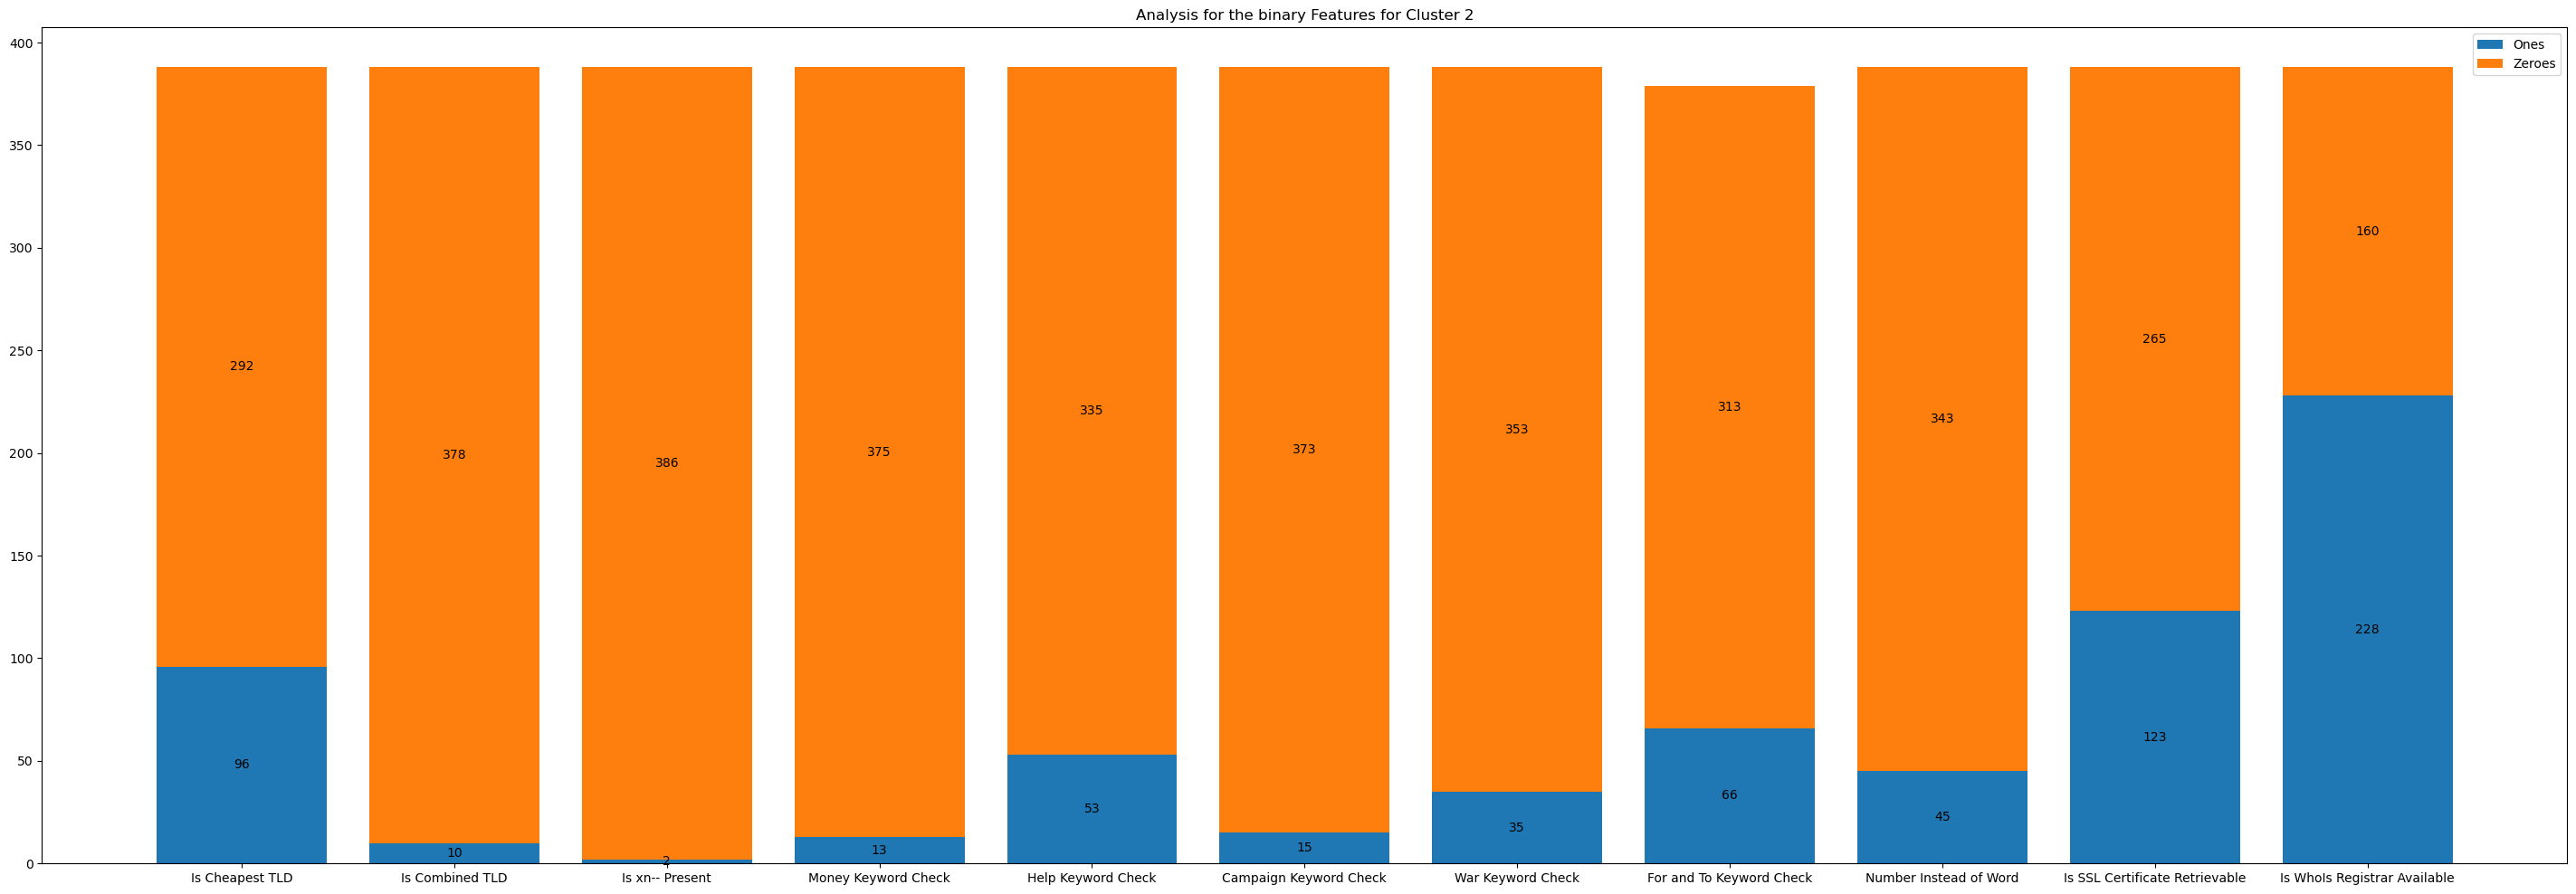

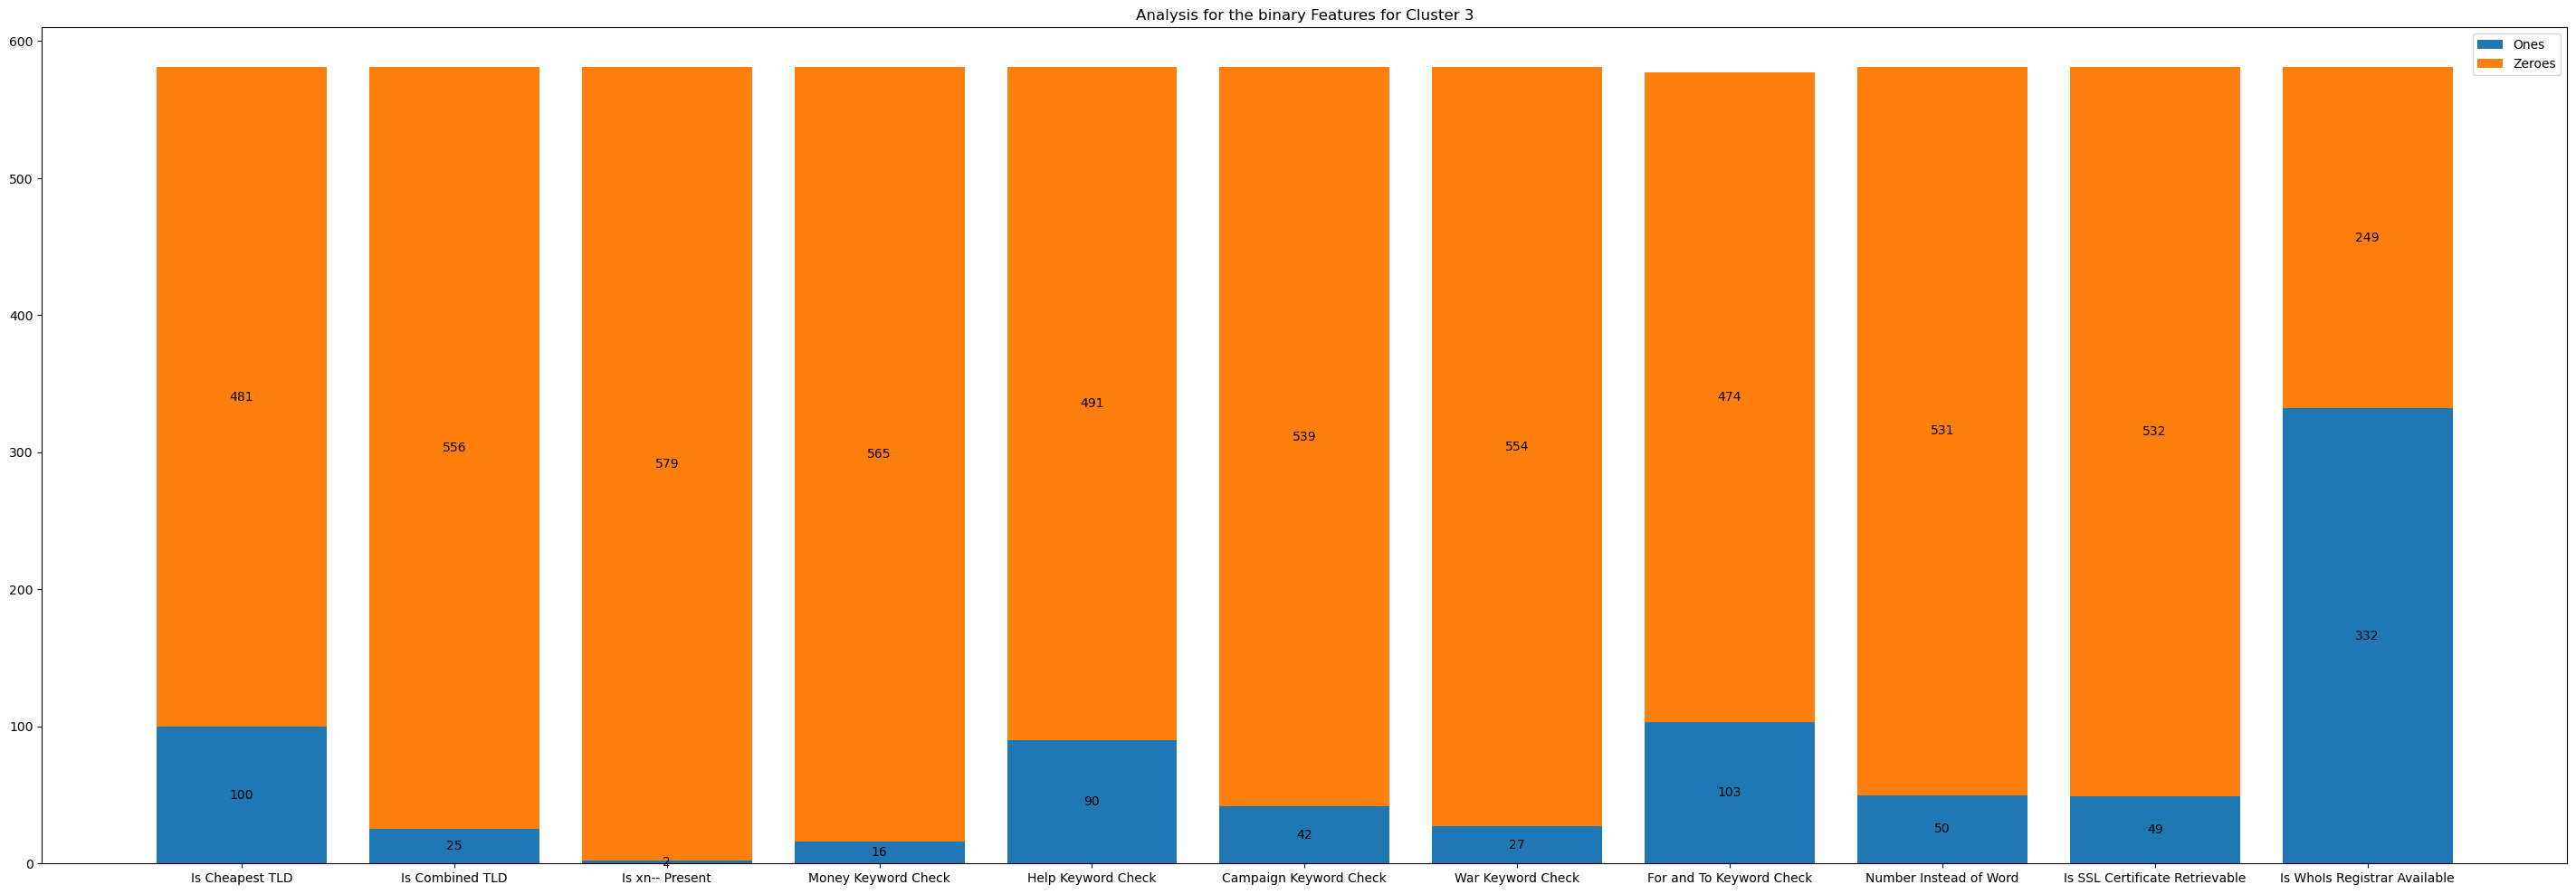

In [39]:
within_cluster_analysis_bin_feature(cluster_1,'Cluster 1')
within_cluster_analysis_bin_feature(cluster_2,'Cluster 2')
within_cluster_analysis_bin_feature(cluster_3,'Cluster 3')

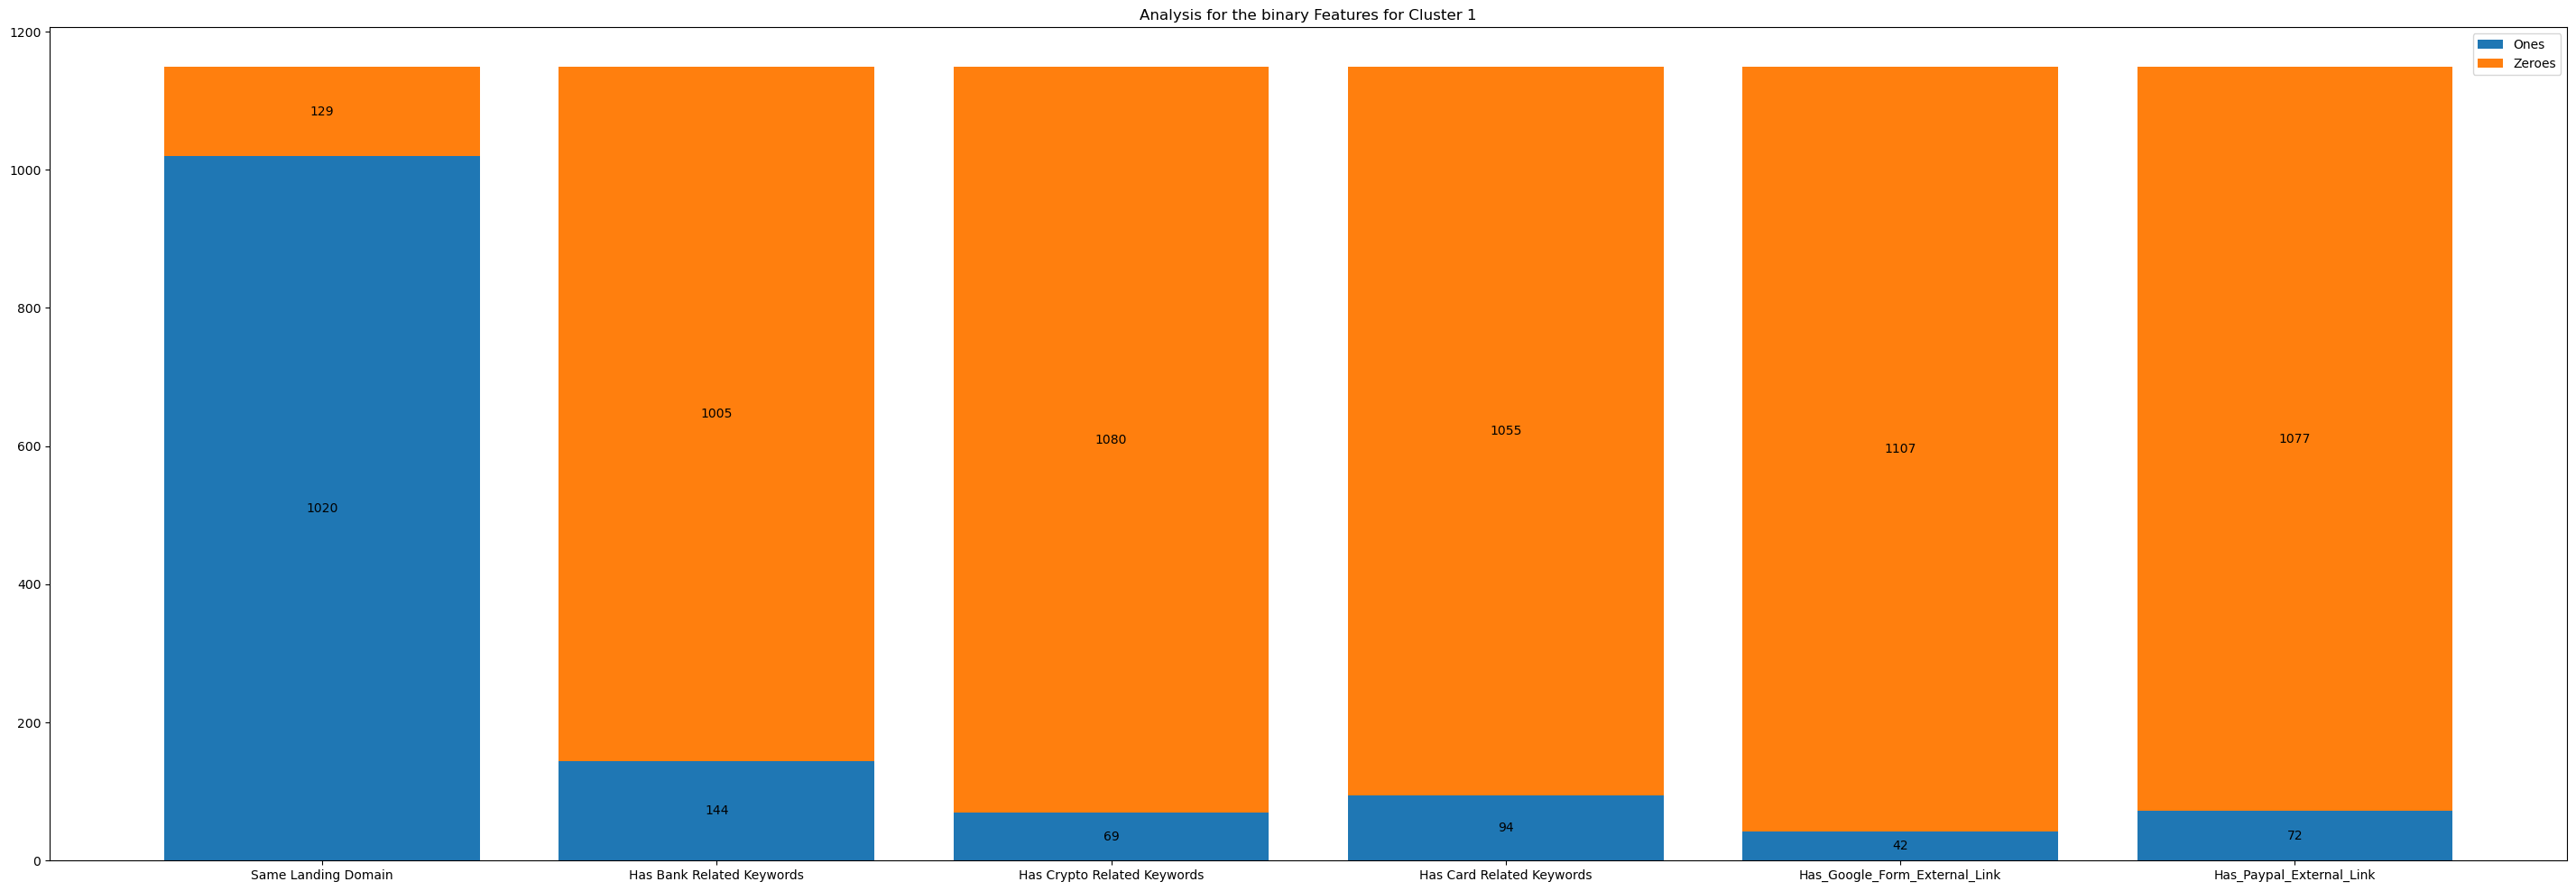

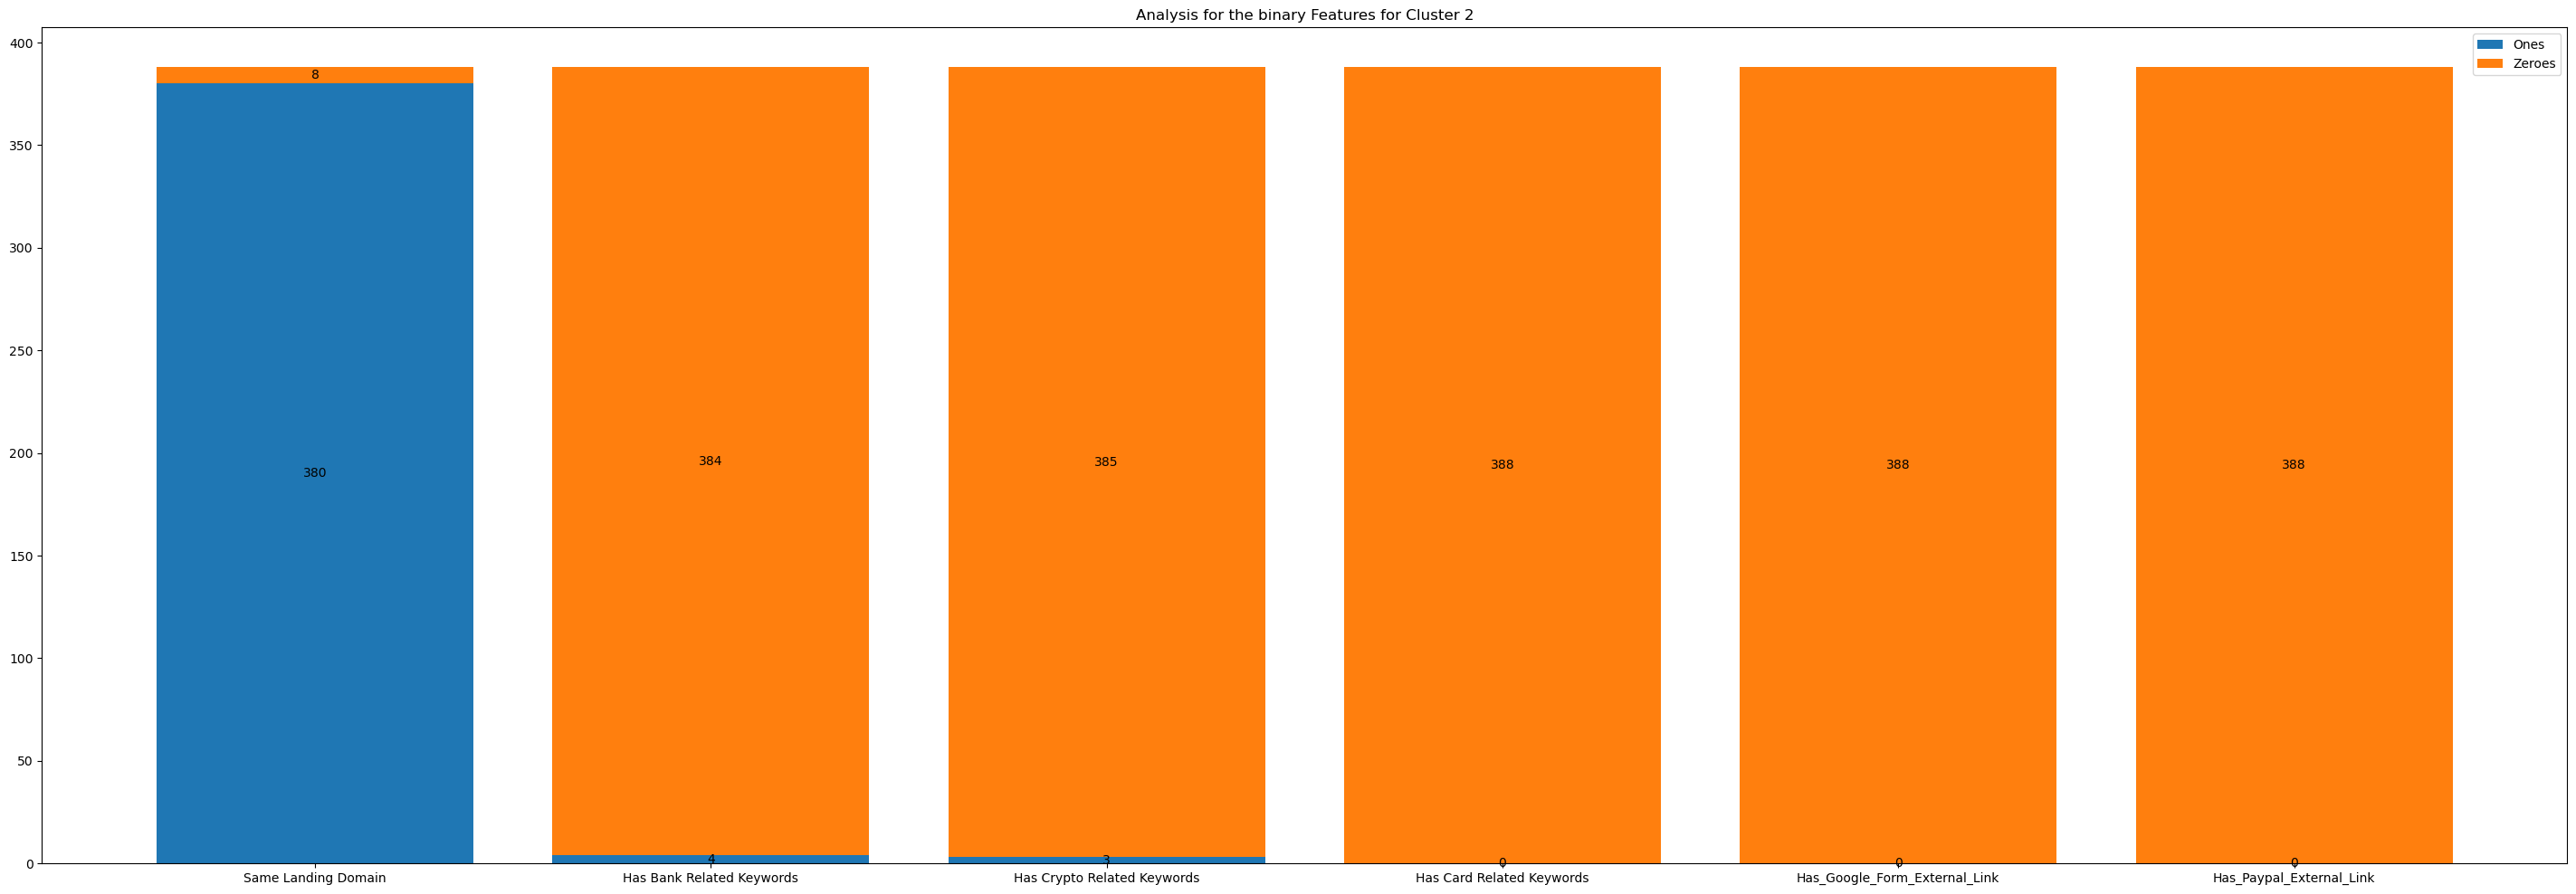

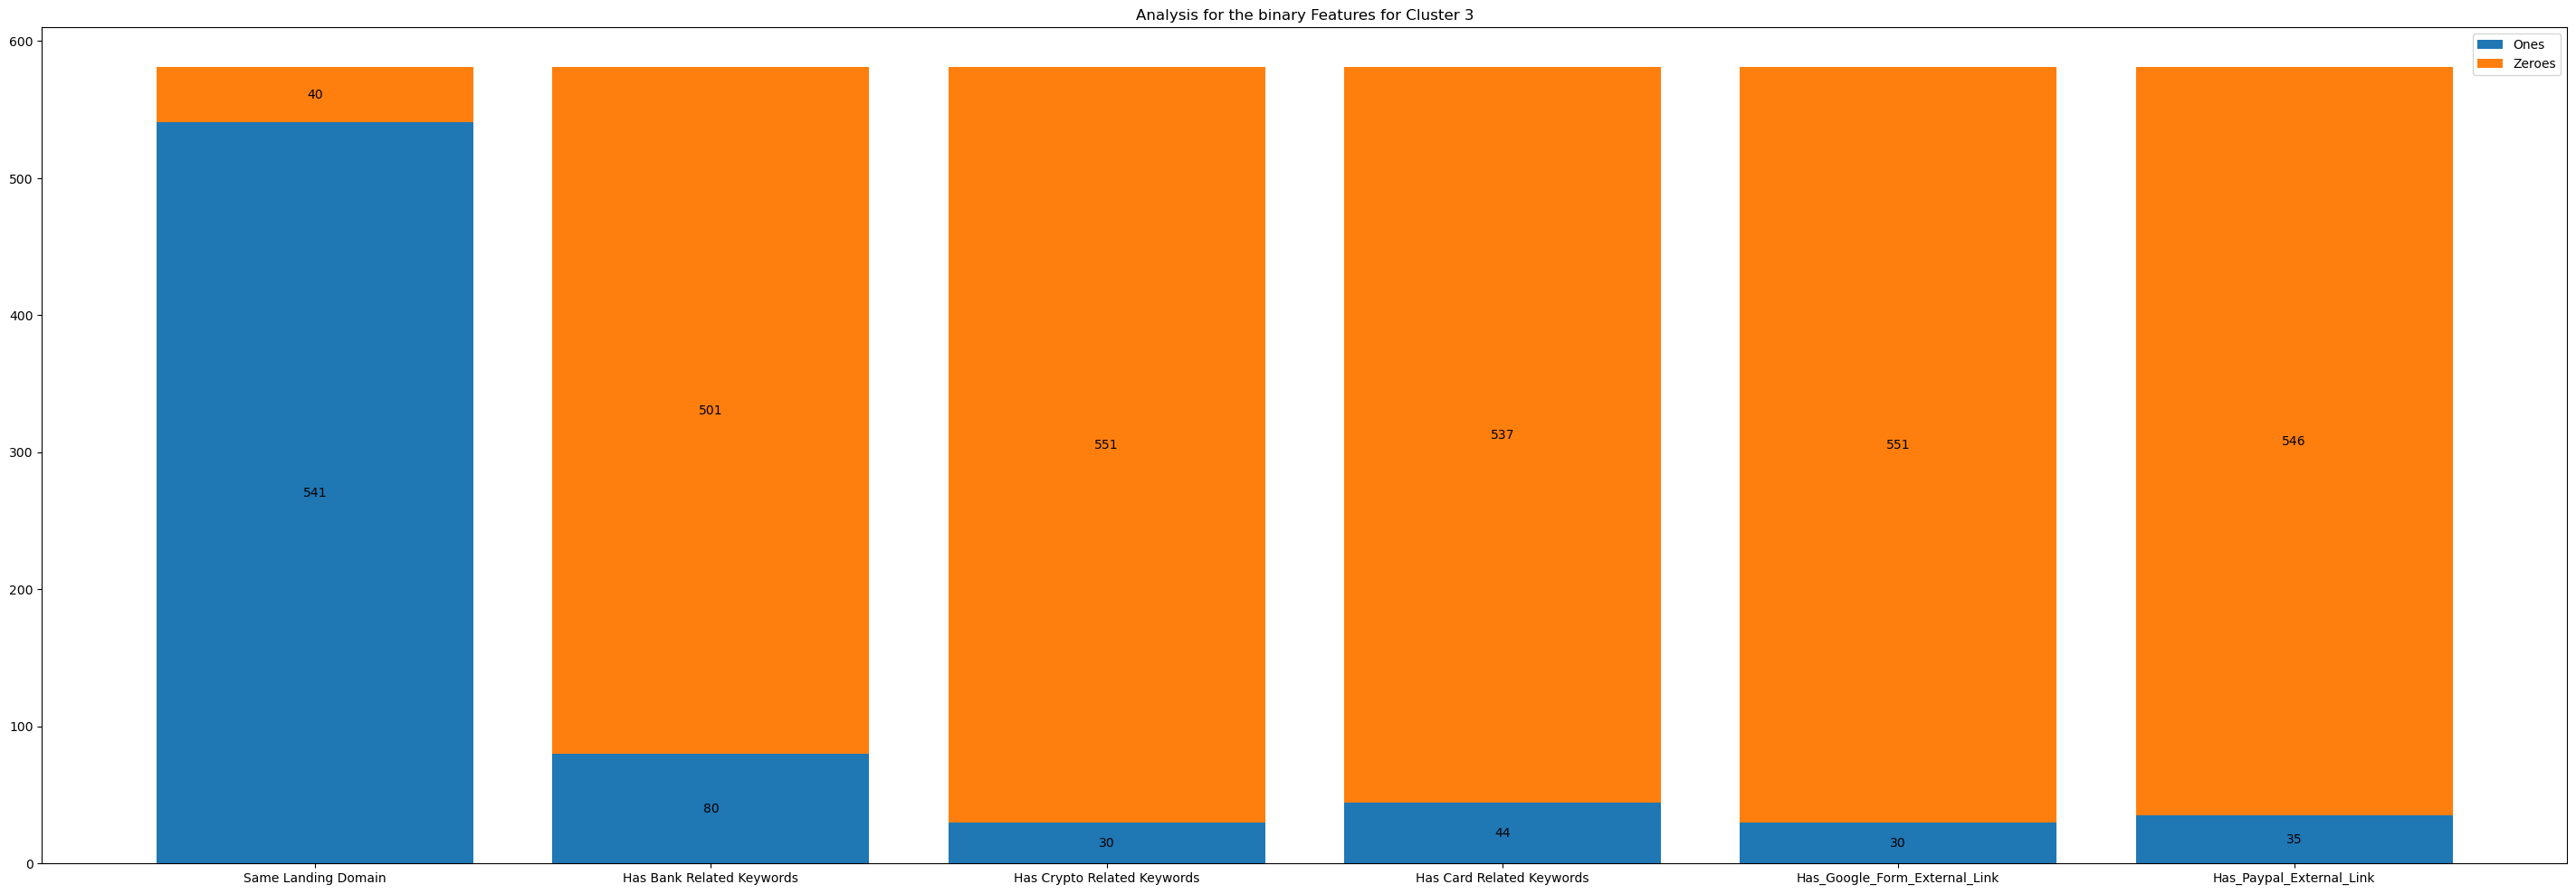

In [40]:
within_cluster_analysis_content_bin_feature(cluster_1,'Cluster 1')
within_cluster_analysis_content_bin_feature(cluster_2,'Cluster 2')
within_cluster_analysis_content_bin_feature(cluster_3,'Cluster 3')

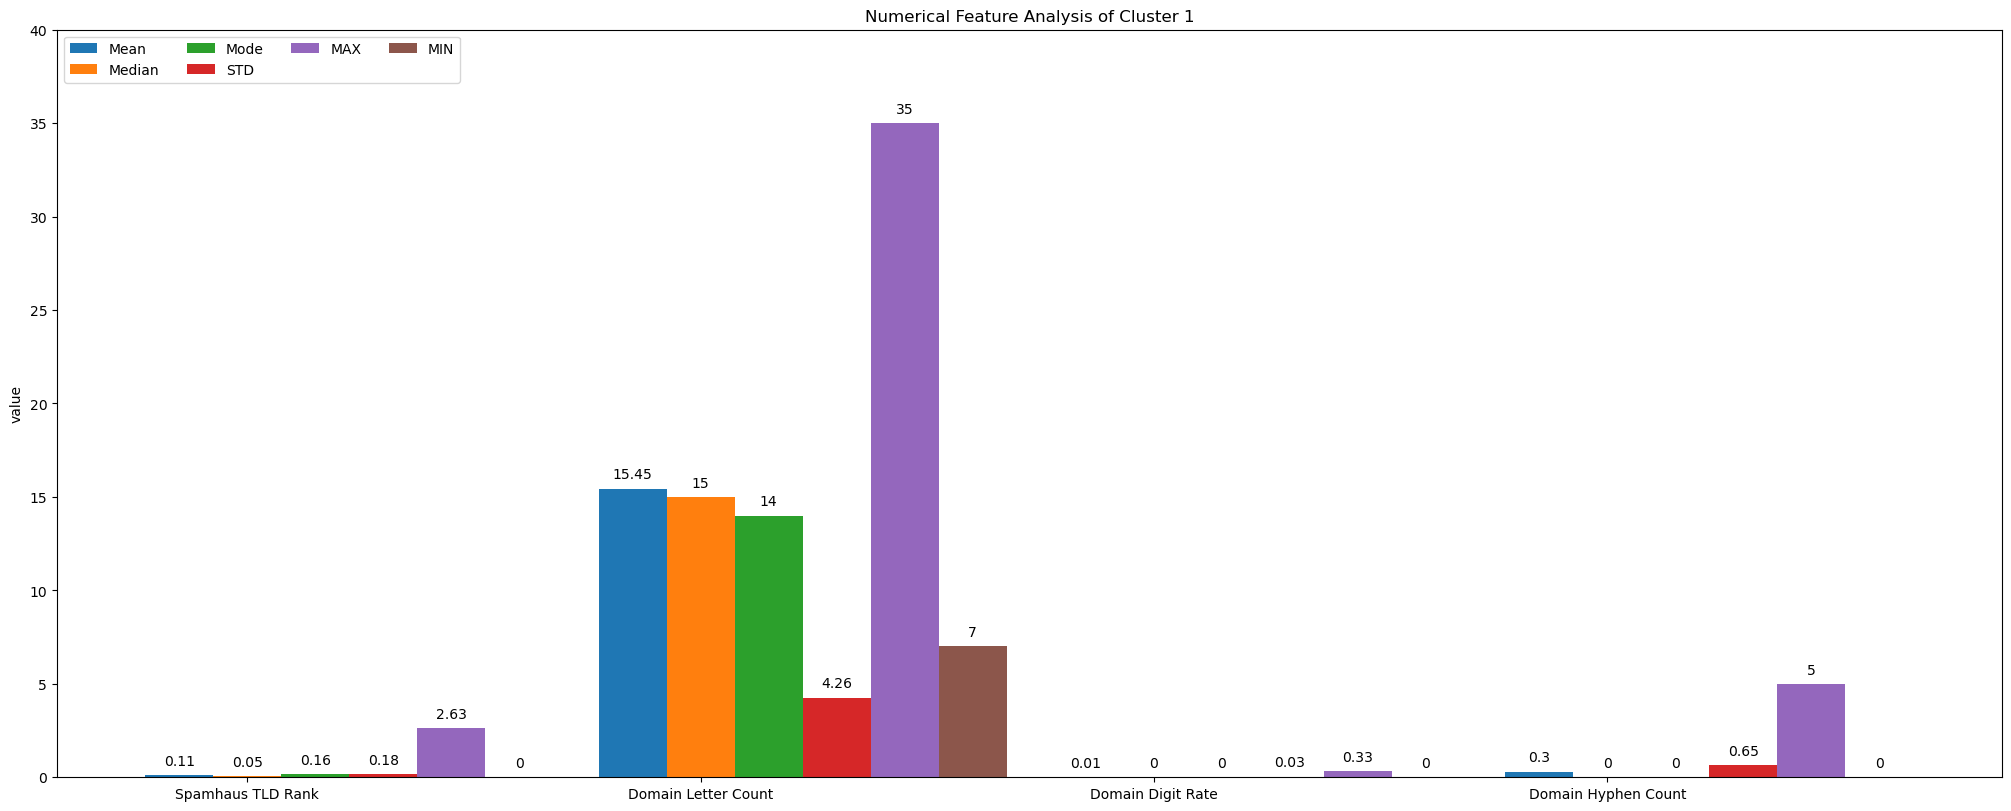

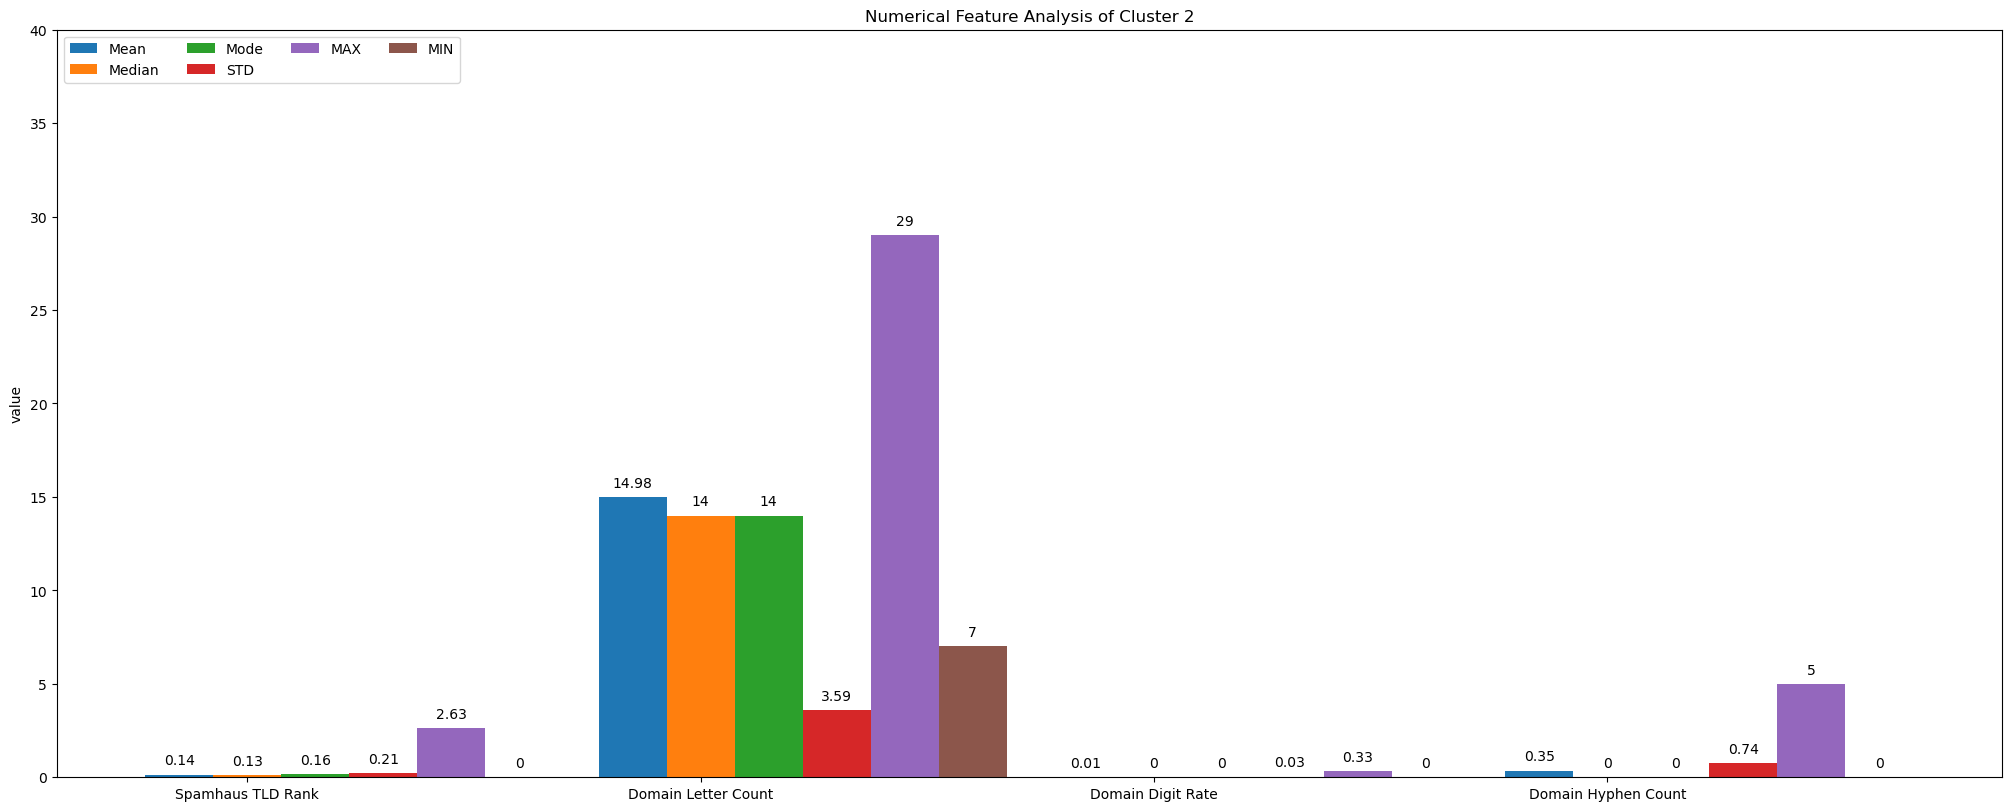

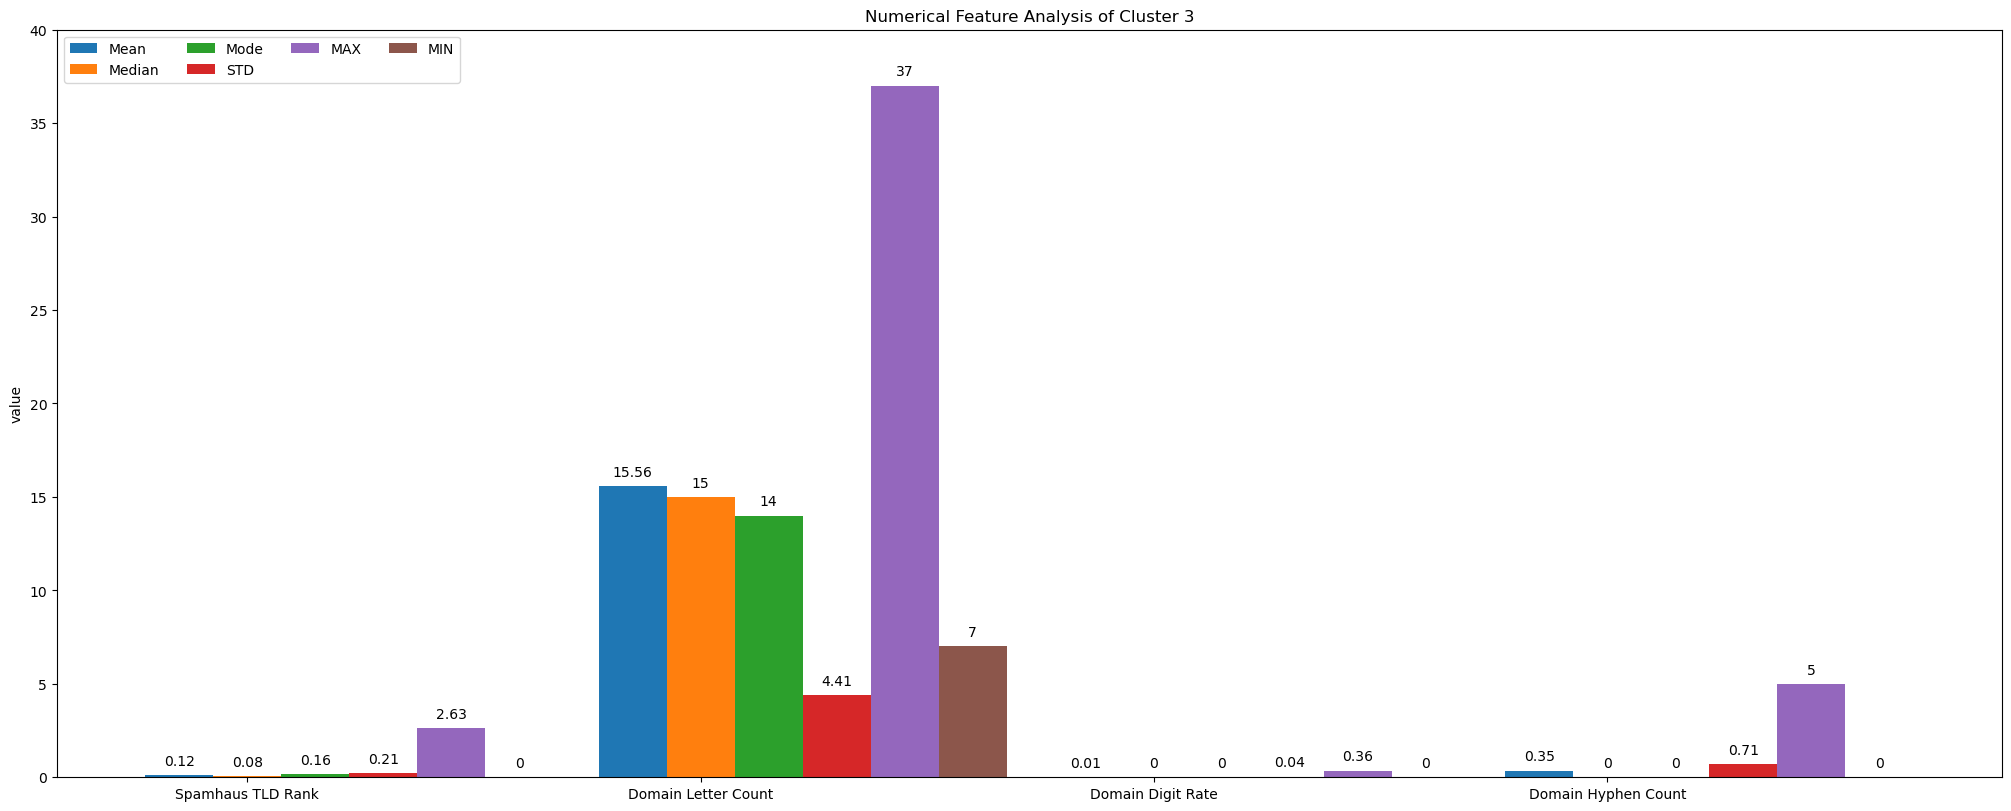

In [41]:
within_cluster_analysis_num_feature(cluster_1,'Cluster 1')
within_cluster_analysis_num_feature(cluster_2,'Cluster 2')
within_cluster_analysis_num_feature(cluster_3,'Cluster 3')

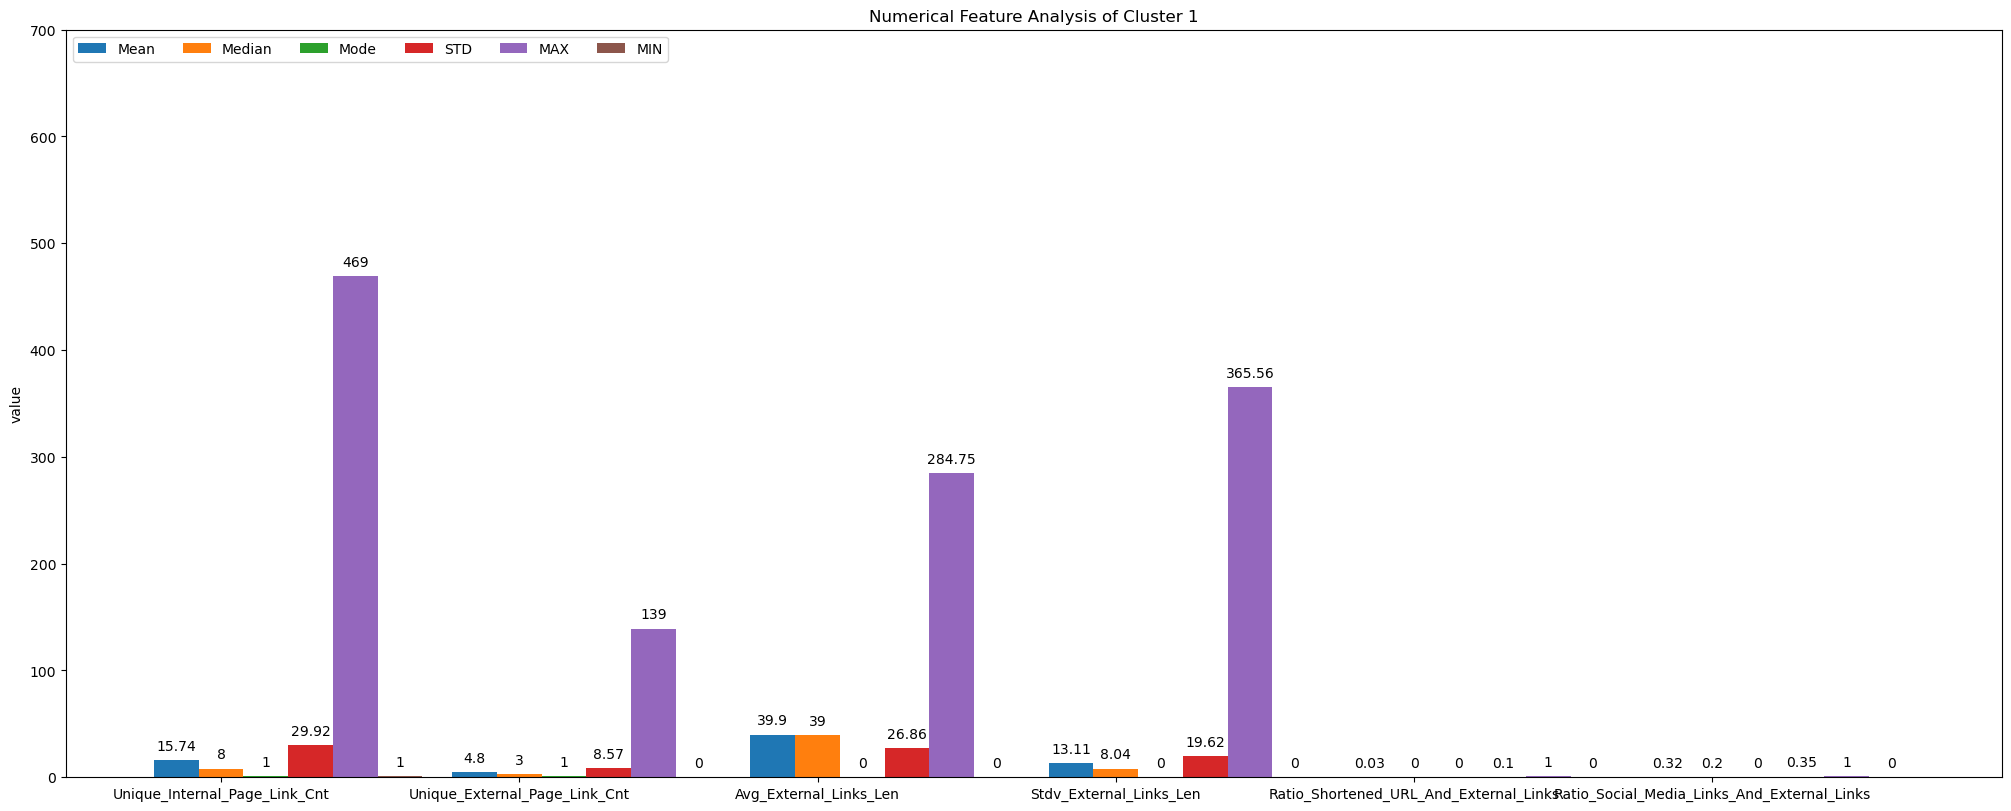

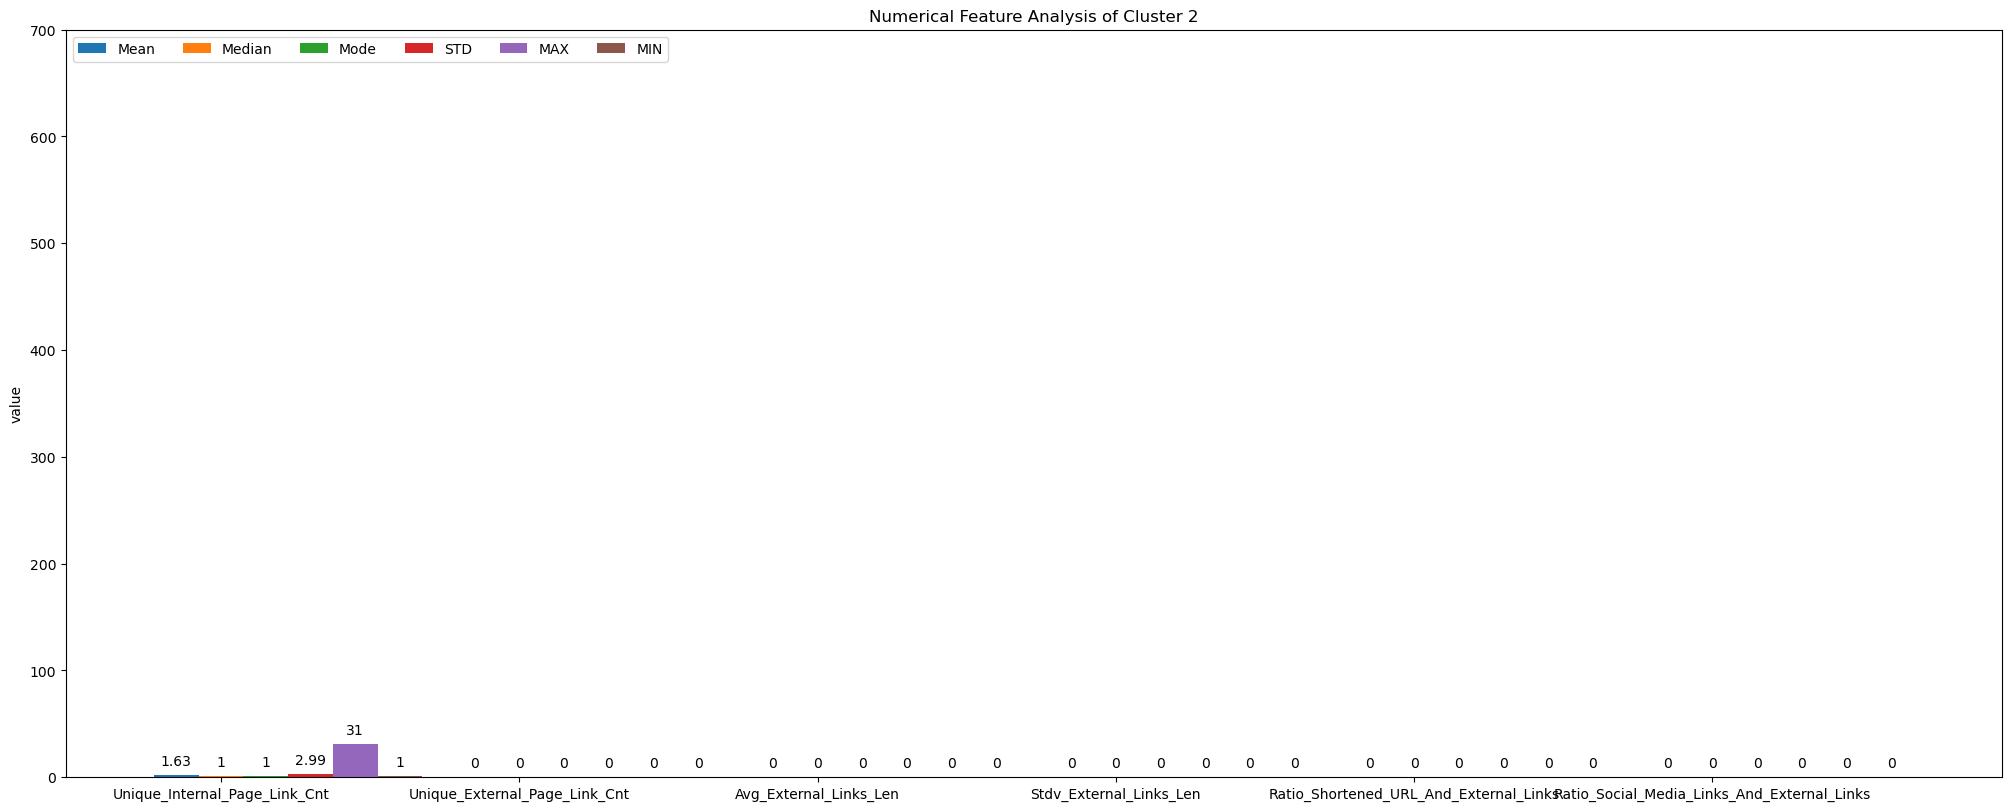

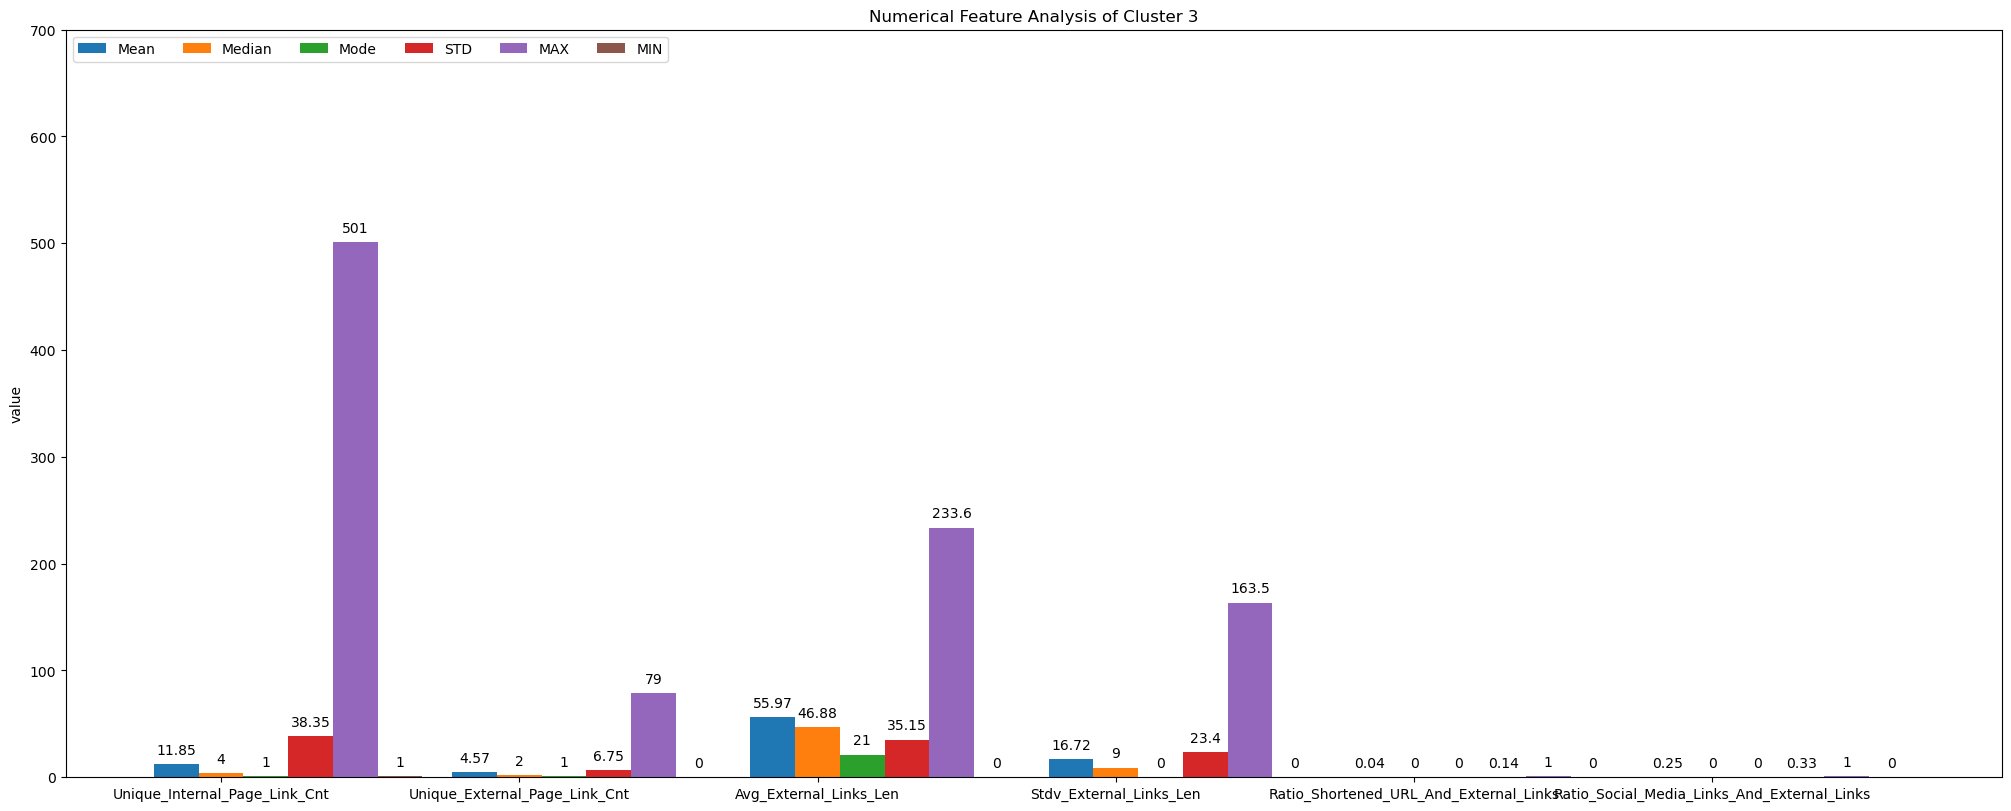

In [42]:
within_cluster_analysis_num_content_feature(cluster_1,'Cluster 1')
within_cluster_analysis_num_content_feature(cluster_2,'Cluster 2')
within_cluster_analysis_num_content_feature(cluster_3,'Cluster 3')

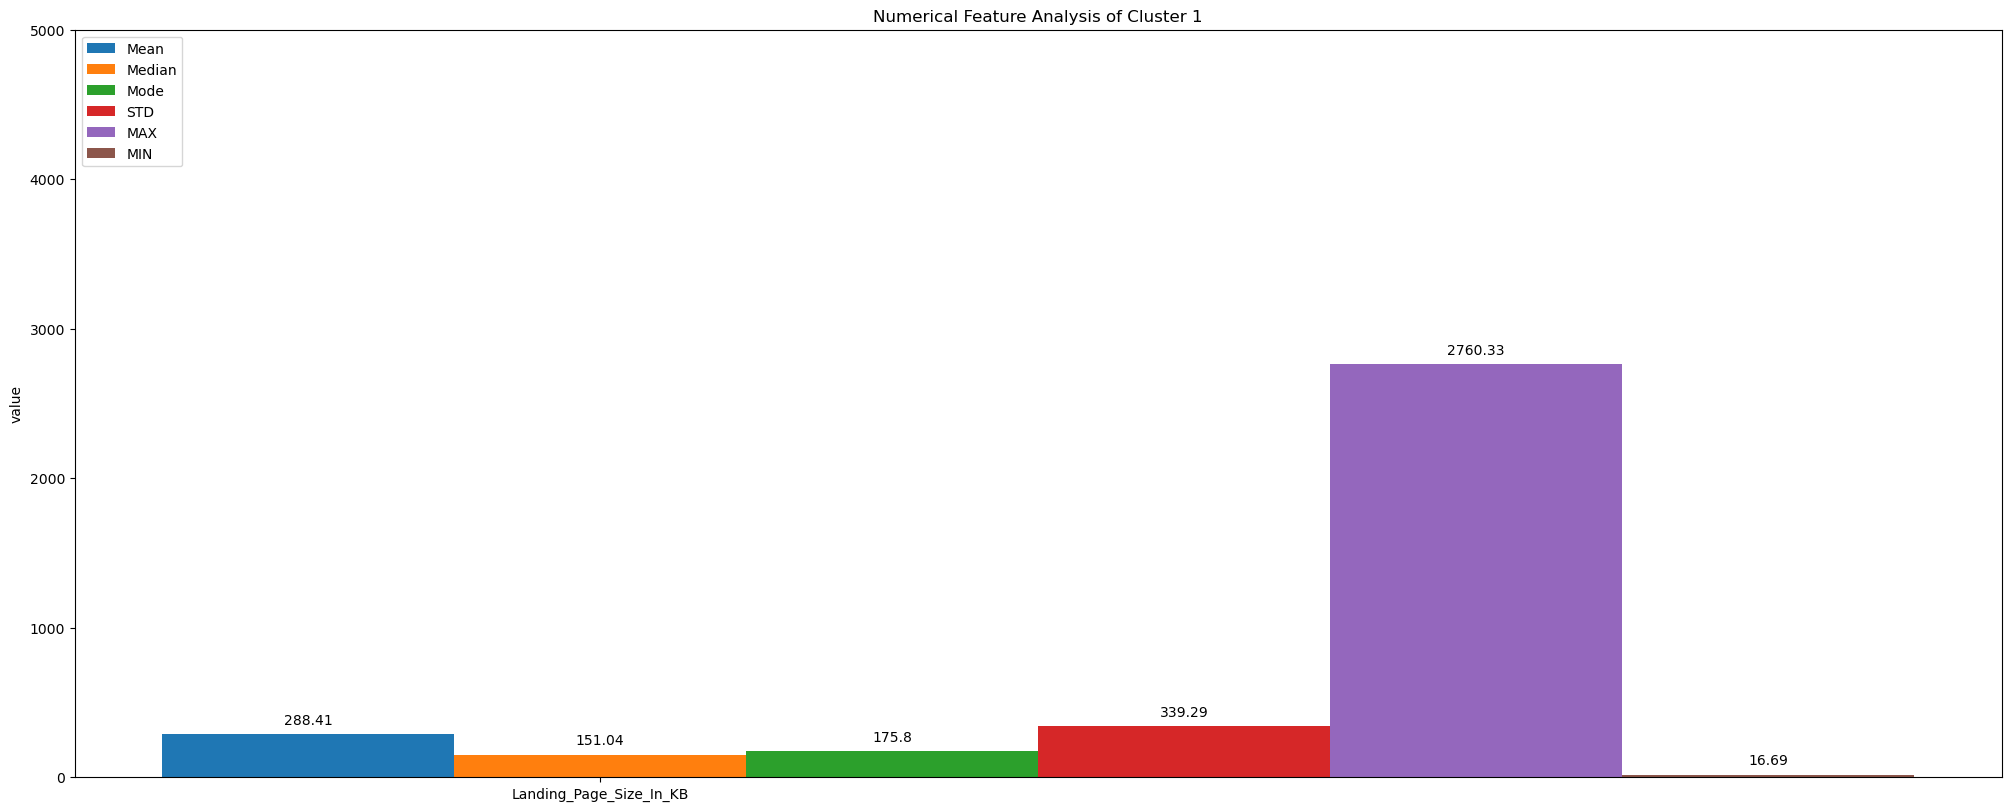

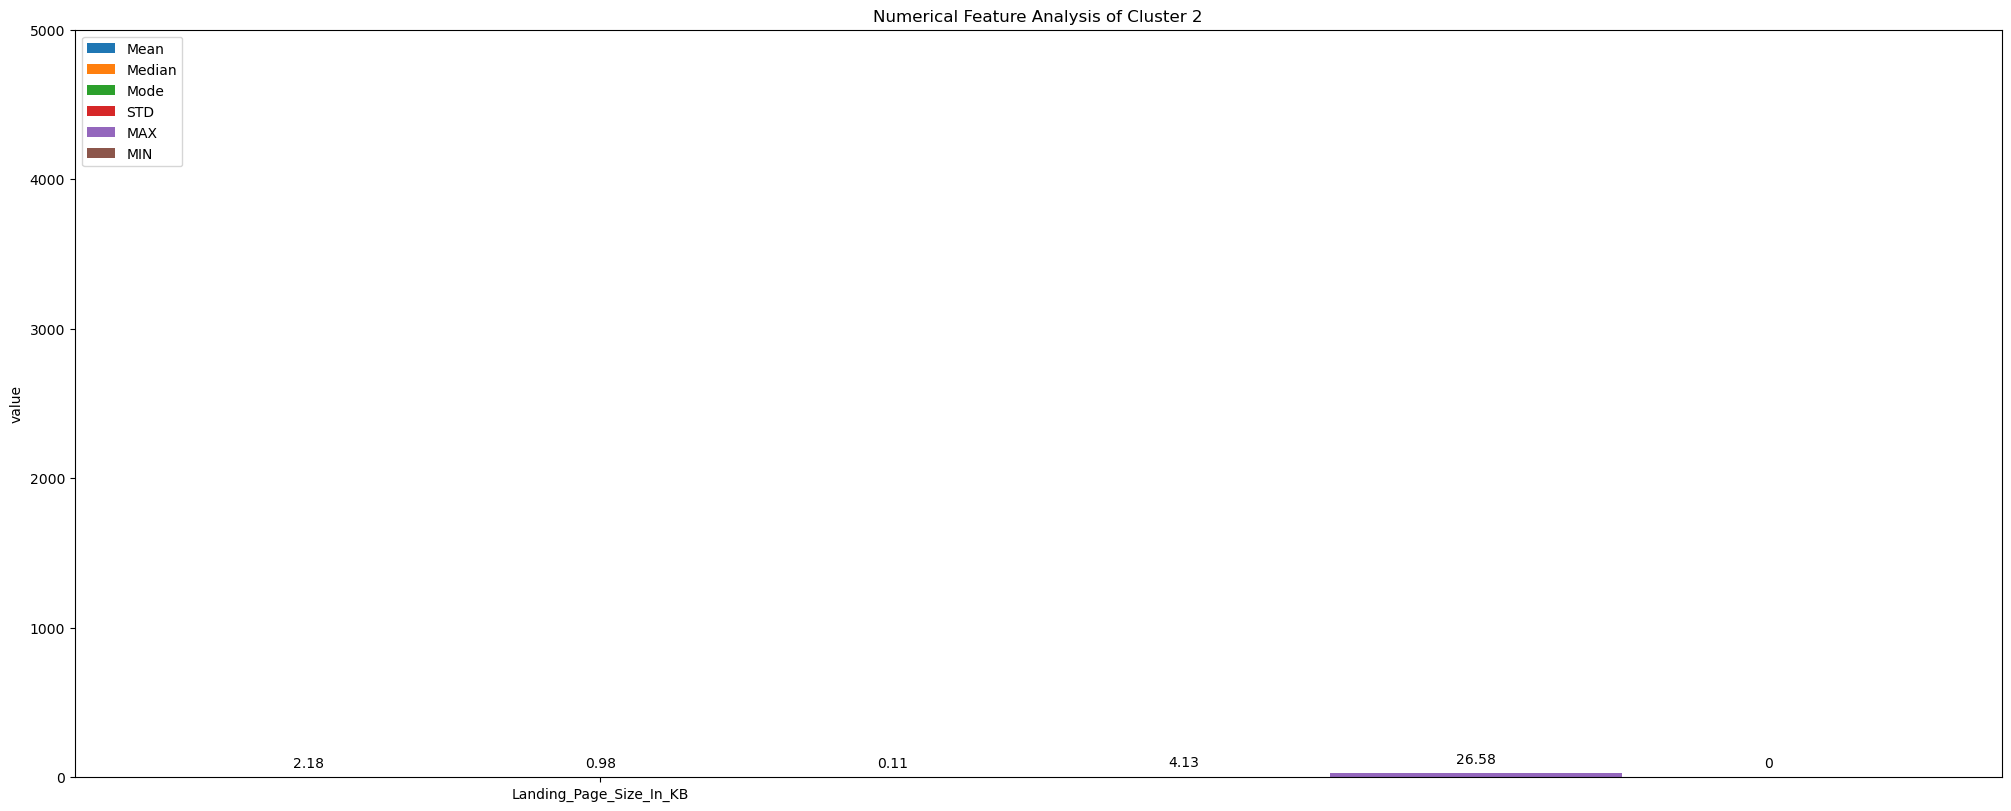

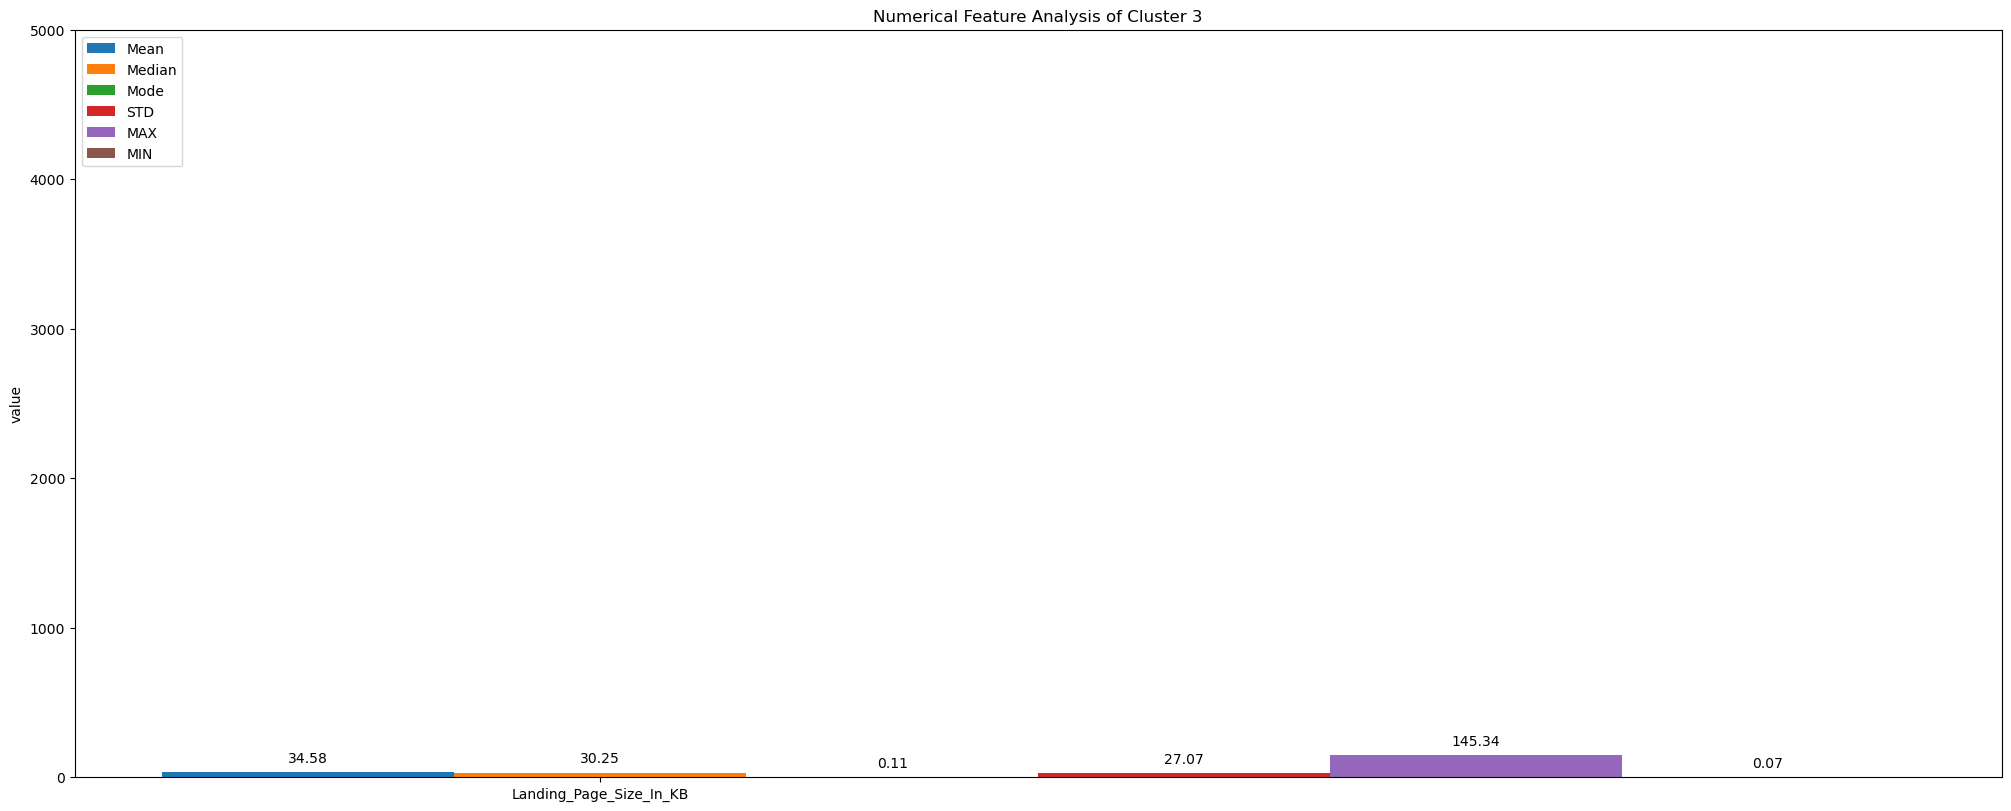

In [43]:
within_cluster_analysis_num_content2_feature(cluster_1,'Cluster 1')
within_cluster_analysis_num_content2_feature(cluster_2,'Cluster 2')
within_cluster_analysis_num_content2_feature(cluster_3,'Cluster 3')